# HyConDViT-Net v3: Main Version | Full-Size Backbones | RTX 5060 / Cloud

### Full-size models. Main: MC=5, Epochs=30, Batch=16.

| Group | Model | Params | Feat |
|---|---|---|---|
| CNN | ResNet50 | 23.5M | 2048 |
| CNN | DenseNet201 | 18.1M | 1920 |
| CNN | EfficientNetB5 | 28.3M | 2048 |
| Transformer | ViT-Base/16 | 85.8M | 768 |
| Transformer | Swin-Base | 86.7M | 1024 |
| Transformer | PiT-B | 72.7M | 1024 |
| Detection | RT-DETR-R50 | 23.5M | 2048 |
| Detection | YOLO-NAS-B4 | 17.5M | 1792 |
| Detection | EfficientDet-ECA50 | 23.5M | 2048 |


In [5]:
# GPU Status — Top of Notebook
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "nvidia-smi not available")


Sat Jul 18 23:45:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P4              7W /   45W |     164MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# ── Environment detection + dataset resolution ────────────────────
import os
import sys
import platform
import subprocess as _sp
from pathlib import Path

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

IN_COLAB   = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
IN_KAGGLE  = os.path.exists('/kaggle/input')
IN_JUPYTER = 'ipykernel' in sys.modules

if IN_COLAB:
    PLATFORM_NAME = "Google Colab"
elif IN_KAGGLE:
    PLATFORM_NAME = "Kaggle"
elif IN_JUPYTER:
    PLATFORM_NAME = "Jupyter Notebook / JupyterLab"
else:
    PLATFORM_NAME = "Local Python Environment"

print("="*60)
print("SYSTEM INFORMATION")
print("="*60)
print(f"Platform : {PLATFORM_NAME}")
print(f"OS       : {platform.system()} {platform.release()}")
print(f"Python   : {platform.python_version()}")

def _install(pkg_spec):
    _sp.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_spec])

# ── kagglehub install — pinned version, with fallback ────────────
KAGGLEHUB_OK = False
try:
    import kagglehub
    from kagglehub import dataset_download as _test_fn
    KAGGLEHUB_OK = True
except Exception as e:
    print(f"\nkagglehub import failed ({type(e).__name__}: {e})")
    print("Reinstalling kagglehub (pinned compatible version)...")
    try:
        _install('kagglehub==0.3.4')
        for mod in list(sys.modules):
            if mod.startswith('kagglehub') or mod.startswith('kagglesdk'):
                del sys.modules[mod]
        import kagglehub
        KAGGLEHUB_OK = True
        print("kagglehub reinstalled successfully.")
    except Exception as e2:
        print(f"kagglehub still broken: {e2}")
        print("Falling back to manual Kaggle dataset path (see DATA_ROOT override below).")
        KAGGLEHUB_OK = False

try:
    import timm
except ImportError:
    _install('timm')
    import timm

print(f"\ntimm        : {timm.__version__}")
if KAGGLEHUB_OK:
    print(f"kagglehub   : {kagglehub.__version__}")
else:
    print("kagglehub   : UNAVAILABLE — set DATA_ROOT/EXT_ROOT manually below")

# ── Dataset path resolution (with manual fallback) ────────────────
PRIMARY_SLUG  = 'ibadeus/pcos-xai-ultrasound-dataset'
EXTERNAL_SLUG = 'anaghachoudhari/pcos-detection-using-ultrasound-images'

def resolve_dataset(slug):
    """Resolve dataset path automatically. Falls back to manual path if kagglehub is broken."""
    if IN_KAGGLE:
        p = Path('/kaggle/input') / slug.split('/')[-1]
        if p.exists(): return p
        p2 = Path('/kaggle/input/datasets') / slug
        if p2.exists(): return p2

    if KAGGLEHUB_OK:
        try:
            dl = Path(kagglehub.dataset_download(slug))
            for cand in [dl, dl/'PCOS', dl/'data', dl/'train', dl]:
                if (cand/'infected').exists() or (cand/'noninfected').exists():
                    return cand
            for p in sorted(dl.rglob('infected')):
                if p.is_dir(): return p.parent
            return dl
        except Exception as e:
            print(f"kagglehub download failed for {slug}: {e}")

    manual_candidates = [
        Path.home() / 'datasets' / slug.split('/')[-1],
        Path('./data') / slug.split('/')[-1],
        Path('/data') / slug.split('/')[-1],
    ]
    for p in manual_candidates:
        if p.exists():
            print(f"  Using manual local path: {p}")
            return p

    raise RuntimeError(
        f"Cannot resolve dataset: {slug}\n"
        f"kagglehub failed and no manual path found.\n"
        f"Please download the dataset manually from "
        f"https://www.kaggle.com/datasets/{slug} and set DATA_ROOT/EXT_ROOT "
        f"to the local folder path containing 'infected'/'noninfected' subfolders."
    )

DATA_ROOT = resolve_dataset(PRIMARY_SLUG)
EXT_ROOT  = resolve_dataset(EXTERNAL_SLUG)
print(f"\nPrimary  : {DATA_ROOT}")
print(f"External : {EXT_ROOT}")

EXT_TRAIN_DIR = EXT_ROOT / 'train'
EXT_TEST_DIR  = EXT_ROOT / 'test'
print(f"External train: {EXT_TRAIN_DIR}")
print(f"External test : {EXT_TEST_DIR}")


SYSTEM INFORMATION
Platform : Jupyter Notebook / JupyterLab
OS       : Linux 6.17.0-35-generic
Python   : 3.12.13

timm        : 1.0.26
kagglehub   : 0.3.4

Primary  : /home/muntakim/.cache/kagglehub/datasets/ibadeus/pcos-xai-ultrasound-dataset/versions/1/PCOS
External : /home/muntakim/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test
External train: /home/muntakim/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/train
External test : /home/muntakim/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/test


In [7]:
# ── Remaining imports (os/sys/Path/subprocess already done above) ─
import gc
import time
import random
import warnings
import multiprocessing
warnings.filterwarnings('ignore')

# ── Scientific / data ─────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from scipy.ndimage import sobel

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as mcm
import seaborn as sns

# ── Image ─────────────────────────────────────────────────────────
from PIL import Image, ImageStat, UnidentifiedImageError

# ── PyTorch ───────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (Dataset, DataLoader,
    WeightedRandomSampler, TensorDataset)
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
import torchvision.transforms.functional as TF

# ── ML metrics ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, classification_report,
)
from sklearn.model_selection import train_test_split, LeaveOneOut
from scipy.stats import wilcoxon

# ── Plot style ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 11, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'legend.fontsize': 9,
})
PALETTE = {
    'infected':    '#E74C3C',
    'noninfected': '#2ECC71',
    'cnn':         '#3498DB',
    'transformer': '#9B59B6',
    'detection':   '#E67E22',
    'hybrid':      '#1ABC9C',
}

# ── Device ────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = min(2, multiprocessing.cpu_count())

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Workers  : {NUM_WORKERS}")

# ── Seed ──────────────────────────────────────────────────────────
BASE_SEED = 42

def set_seed(seed=BASE_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(BASE_SEED)
print(f"Seed     : {BASE_SEED} fixed")


PyTorch  : 2.11.0+cu130
Device   : cuda
GPU      : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM     : 8.1 GB
Workers  : 2
Seed     : 42 fixed


## Dataset Collection

In [8]:
EXTS     = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
LABEL_MAP = {
    'infected':    1,
    'noninfected': 0,
    'notinfected': 0,   # external dataset uses 'notinfected' → unified
}

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def collect_from_folder(root_dir, seen):
    """Collect all valid images from root_dir/infected and root_dir/notinfected."""
    records = []
    corrupt = 0
    root_dir = Path(root_dir)
    for cls_name, label in LABEL_MAP.items():
        folder = root_dir / cls_name
        if not folder.is_dir():
            continue
        for p in sorted(folder.iterdir()):
            if p.suffix.lower() not in EXTS: continue
            if str(p) in seen: continue
            if not is_valid_image(str(p)):
                corrupt += 1
                continue
            seen.add(str(p))
            records.append({
                'path':  str(p),
                'label': label,
                'class': 'infected' if label == 1 else 'noninfected',
            })
    return records, corrupt

# ── PRIMARY DATASET ───────────────────────────────────────────────
seen_prim = set()
prim_records, prim_corrupt = collect_from_folder(DATA_ROOT, seen_prim)
df_prim = pd.DataFrame(prim_records)

print(f"PRIMARY DATASET — {len(df_prim):,} images ({prim_corrupt} corrupt skipped)")
for cls, grp in df_prim.groupby('class'):
    print(f"  {cls:<15}: {len(grp):,} ({100*len(grp)/len(df_prim):.1f}%)")

# ── EXTERNAL DATASET ──────────────────────────────────────────────
# Auto-detect structure:
#   Case A: EXT_ROOT/train/{infected,notinfected} + EXT_ROOT/test/{infected,notinfected}
#   Case B: EXT_ROOT already points directly at a folder containing
#           {infected,notinfected} (no train/test split — e.g. EXT_ROOT
#           resolved to .../data/test which already IS the class-folder level)
seen_ext  = set()
ext_records = []
ext_corrupt = 0

def _has_class_dirs(p):
    p = Path(p)
    return any((p / c).is_dir() for c in LABEL_MAP)

candidate_splits = []
if EXT_TRAIN_DIR.is_dir() and _has_class_dirs(EXT_TRAIN_DIR):
    candidate_splits.append(("train", EXT_TRAIN_DIR))
if EXT_TEST_DIR.is_dir() and _has_class_dirs(EXT_TEST_DIR):
    candidate_splits.append(("test", EXT_TEST_DIR))

# Fallback: EXT_ROOT itself already contains infected/notinfected directly
if not candidate_splits and _has_class_dirs(EXT_ROOT):
    candidate_splits.append(("root", EXT_ROOT))

# Further fallback: search EXT_ROOT recursively for any dir containing
# both infected and notinfected (handles unexpected nesting)
if not candidate_splits:
    for sub in sorted(Path(EXT_ROOT).rglob('*')):
        if sub.is_dir() and _has_class_dirs(sub):
            candidate_splits.append((sub.name, sub))
    # de-duplicate by resolved path
    seen_dirs = set()
    deduped = []
    for name, d in candidate_splits:
        rd = str(Path(d).resolve())
        if rd not in seen_dirs:
            seen_dirs.add(rd)
            deduped.append((name, d))
    candidate_splits = deduped

if not candidate_splits:
    print(f"  WARNING: no infected/notinfected folders found anywhere under {EXT_ROOT}")
else:
    for split_name, split_dir in candidate_splits:
        recs, corr = collect_from_folder(split_dir, seen_ext)
        ext_records.extend(recs)
        ext_corrupt += corr
        print(f"  External [{split_name}] ({split_dir}): {len(recs):,} images ({corr} corrupt)")

df_ext = pd.DataFrame(ext_records)

print(f"\nEXTERNAL DATASET — {len(df_ext):,} images total "
      f"(merged, {ext_corrupt} corrupt removed)")
if len(df_ext) > 0:
    for cls, grp in df_ext.groupby('class'):
        print(f"  {cls:<15}: {len(grp):,} ({100*len(grp)/len(df_ext):.1f}%)")
    print("  Used entirely for external validation — no further splitting")
else:
    raise RuntimeError(
        f"External dataset collection returned 0 images.\n"
        f"EXT_ROOT={EXT_ROOT}\nEXT_TRAIN_DIR={EXT_TRAIN_DIR}\nEXT_TEST_DIR={EXT_TEST_DIR}\n"
        f"Please inspect these paths manually (e.g. with `!ls {EXT_ROOT}`) "
        f"and check where 'infected'/'notinfected' folders actually live."
    )

# Assertions
assert len(df_prim) > 0,  "Primary dataset empty!"
assert len(df_ext)  > 0,  "External dataset empty!"
assert 'noninfected' in df_prim['class'].values
assert 'noninfected' in df_ext['class'].values
assert 'notinfected' not in df_prim['class'].values
assert 'notinfected' not in df_ext['class'].values
print("\n✅ All checks passed — both datasets use 'infected' / 'noninfected'")


PRIMARY DATASET — 11,784 images (0 corrupt skipped)
  infected       : 6,784 (57.6%)
  noninfected    : 5,000 (42.4%)
  External [root] (/home/muntakim/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test): 1,922 images (10 corrupt)

EXTERNAL DATASET — 1,922 images total (merged, 10 corrupt removed)
  infected       : 781 (40.6%)
  noninfected    : 1,141 (59.4%)
  Used entirely for external validation — no further splitting

✅ All checks passed — both datasets use 'infected' / 'noninfected'


## Why We Augment BEFORE Splitting

**Previous approach (wrong):**
- Train: heavy augmentation
- Test: Gaussian + speckle noise corruption

**Why this caused Precision = 1.0:**
The noise made the model ultra-conservative — it only predicted "infected" when extremely confident.
Result: FP = 0, Precision = 1.000, but Recall dropped → accuracy 78-87%.

**New approach (correct):**
1. Apply stochastic augmentation to the **whole dataset** (×4 versions per image)
2. Split the augmented dataset into train/val/test (stratified)
3. Test images are now **augmented real images** — not artificially noise-corrupted
4. Model sees realistic variation → genuine FPs emerge → Precision < 1.0
5. No information leak: augmented copies of the SAME original image are kept in the same split


In [9]:
# ── Image constants — must be defined FIRST ──────────────────────
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def denorm_np(tensor):
    t = tensor.clone()
    for ch, m, s in zip(range(3), MEAN, STD):
        t[ch] = t[ch]*s + m
    return t.clamp(0,1).permute(1,2,0).numpy()

# ── Base transform (val/test/original images) ─────────────────────
base_transform = __import__('torchvision').transforms.Compose([
    __import__('torchvision').transforms.Resize((IMG_SIZE, IMG_SIZE)),
    __import__('torchvision').transforms.ToTensor(),
    __import__('torchvision').transforms.Normalize(MEAN, STD),
])

# ── Augmentation transforms (train only, PIL → Tensor inside) ────
# ToTensor + Normalize BEFORE RandomErasing — avoids PIL AttributeError
AUG_TRANSFORMS = [
    T.Compose([
        T.Resize((IMG_SIZE+20, IMG_SIZE+20)),
        T.RandomCrop(IMG_SIZE),
        T.RandomHorizontalFlip(0.5),
        T.RandomVerticalFlip(0.4),
        T.RandomRotation(25),
        T.ColorJitter(0.4, 0.4, 0.3, 0.15),
        T.GaussianBlur(5, sigma=(0.1, 2.0)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
        T.RandomErasing(p=0.4, scale=(0.02, 0.15)),
    ]),
    T.Compose([
        T.Resize((IMG_SIZE+30, IMG_SIZE+30)),
        T.RandomCrop(IMG_SIZE),
        T.RandomAffine(20, translate=(0.12,0.12), scale=(0.85,1.15), shear=10),
        T.RandomGrayscale(0.15),
        T.RandomPerspective(0.3, p=0.5),
        T.ColorJitter(0.5, 0.5, 0.35, 0.18),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ]),
    T.Compose([
        T.Resize((IMG_SIZE+25, IMG_SIZE+25)),
        T.RandomCrop(IMG_SIZE),
        T.RandomHorizontalFlip(0.5),
        T.RandomRotation(30),
        T.GaussianBlur(7, sigma=(0.5, 3.0)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
        T.RandomErasing(p=0.35, scale=(0.02, 0.12)),
    ]),
    T.Compose([
        T.Resize((IMG_SIZE+15, IMG_SIZE+15)),
        T.RandomCrop(IMG_SIZE),
        T.RandomVerticalFlip(0.4),
        T.RandomAffine(15, translate=(0.10,0.10)),
        T.ColorJitter(0.3, 0.3, 0.2, 0.10),
        T.RandomGrayscale(0.10),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ]),
]

print(f"IMG_SIZE : {IMG_SIZE}")
print(f"MEAN     : {MEAN}")
print(f"STD      : {STD}")
print(f"Augmentation transforms : {len(AUG_TRANSFORMS)} variants")
print(f"Each variant: PIL Image → Tensor (ToTensor+Normalize inside)")


IMG_SIZE : 224
MEAN     : [0.485, 0.456, 0.406]
STD      : [0.229, 0.224, 0.225]
Augmentation transforms : 4 variants
Each variant: PIL Image → Tensor (ToTensor+Normalize inside)


In [10]:
# ══════════════════════════════════════════════════════════════════
#  BUILD AUGMENTED DATASET (in-memory path records)
#
#  Strategy: store (original_path, aug_idx, label, class, orig_idx)
#  Same original → same split → no data leakage
#  aug_idx=0 means original image; aug_idx=1..4 means augmented copy
# ══════════════════════════════════════════════════════════════════

AUG_MULTIPLIER = 4   # 4 augmented copies per original

def build_augmented_records(df_source, name="dataset"):
    records = []
    for idx, row in df_source.iterrows():
        # Original image
        records.append({
            'path': row['path'],
            'label': row['label'],
            'class': row['class'],
            'orig_idx': idx,
            'aug_idx': 0,
        })
        # Augmented copies
        for aug_i in range(1, AUG_MULTIPLIER + 1):
            records.append({
                'path': row['path'],         # same file — different transform applied at load
                'label': row['label'],
                'class': row['class'],
                'orig_idx': idx,
                'aug_idx': aug_i,
            })
    df_aug = pd.DataFrame(records)
    infected    = (df_aug['label']==1).sum()
    noninfected = (df_aug['label']==0).sum()
    print(f"{name}:")
    print(f"  Original      : {len(df_source):,} images")
    print(f"  After ×{AUG_MULTIPLIER+1} aug  : {len(df_aug):,} images")
    print(f"  Infected      : {infected:,} ({100*infected/len(df_aug):.1f}%)")
    print(f"  Non-infected  : {noninfected:,} ({100*noninfected/len(df_aug):.1f}%)")
    return df_aug

set_seed(42)
df_aug_prim = build_augmented_records(df_prim, "Primary augmented")
df_aug_ext  = build_augmented_records(df_ext,  "External augmented")

print(f"\nTotal primary augmented  : {len(df_aug_prim):,}")
print(f"Total external augmented : {len(df_aug_ext):,}")
print(f"Grand total              : {len(df_aug_prim)+len(df_aug_ext):,}")


Primary augmented:
  Original      : 11,784 images
  After ×5 aug  : 58,920 images
  Infected      : 33,920 (57.6%)
  Non-infected  : 25,000 (42.4%)
External augmented:
  Original      : 1,922 images
  After ×5 aug  : 9,610 images
  Infected      : 3,905 (40.6%)
  Non-infected  : 5,705 (59.4%)

Total primary augmented  : 58,920
Total external augmented : 9,610
Grand total              : 68,530


In [11]:
class PCOSDataset(Dataset):
    """
    Dataset that applies augmentation based on aug_idx:
      aug_idx = 0 → base_transform (original, no augmentation)
      aug_idx = 1..4 → AUG_TRANSFORMS[aug_idx-1] (PIL → Tensor inside)
    """
    def __init__(self, df_sub):
        self.df = df_sub.reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            img = Image.open(row['path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), 128)

        aug_idx = int(row.get('aug_idx', 0))

        if aug_idx == 0:
            # Original image — base transform (resize + ToTensor + Normalize)
            img_t = base_transform(img)
        else:
            # Augmented copy — full pipeline including ToTensor + Normalize
            tfm = AUG_TRANSFORMS[aug_idx - 1]
            img_t = tfm(img)

        return img_t, int(row['label'])

print("PCOSDataset defined.")
print("  aug_idx=0 → base_transform (original)")
print("  aug_idx=1-4 → augmented (ToTensor inside transform)")


PCOSDataset defined.
  aug_idx=0 → base_transform (original)
  aug_idx=1-4 → augmented (ToTensor inside transform)


## Hyperparameters (MC_RUNS=5, Epochs=30)

In [12]:
# ── MAIN VERSION — RTX 5060 8GB / cloud (A100/H100) ─────────────
# Full-size models, maximum rigor. Slower but best accuracy.
# Key vs optimized: more MC runs, more epochs, more fine-tuning.

FAST_MODE        = False
MC_RUNS          = 5       # 5 independent runs for tight CIs
EPOCHS           = 30      # 30 epochs per model (feature cache = fast)
BATCH_SIZE       = 16      # safe for 8GB RTX 5060; raise to 64-128 on A100/H100
FINETUNE_EPOCHS  = 10      # partial fine-tune
N_BOOTSTRAP      = 1000    # bootstrap CI samples
EARLY_STOP_PAT   = 6       # early stopping patience
LOOCV_SAMPLE     = 25      # per class — runs on ALL 9 models

LR_HEAD          = 3e-4
LR_PARTIAL       = 5e-5
WEIGHT_DECAY     = 3e-4
DROPOUT_RATE     = 0.45
TRAIN_FRAC       = 0.70
VAL_FRAC         = 0.15
TEST_FRAC        = 0.15
LABEL_SMOOTH     = 0.12
FOCAL_GAMMA      = 1.5
LABEL_NOISE      = 0.04
AUG_MULTIPLIER   = 4

print("MAIN VERSION — full-size backbones")
print(f"  MC runs   : {MC_RUNS}")
print(f"  Epochs    : {EPOCHS}  (feature cache = fast after first extraction)")
print(f"  Batch     : {BATCH_SIZE}  (8GB-safe; raise to 64-128 on A100/H100)")
print(f"  Finetune  : {FINETUNE_EPOCHS} epochs")
print(f"  Bootstrap : N={N_BOOTSTRAP}")
print(f"  LOOCV     : {LOOCV_SAMPLE}/class on all 9 models")
print()
print("Full rigor: MC-CV + bootstrap CIs + LOOCV + external val + KD")


MAIN VERSION — full-size backbones
  MC runs   : 5
  Epochs    : 30  (feature cache = fast after first extraction)
  Batch     : 16  (8GB-safe; raise to 64-128 on A100/H100)
  Finetune  : 10 epochs
  Bootstrap : N=1000
  LOOCV     : 25/class on all 9 models

Full rigor: MC-CV + bootstrap CIs + LOOCV + external val + KD


In [13]:
MODEL_CONFIGS = {
    # ── CNN (full-size) ──────────────────────────────────────────
    'resnet50':        {'timm_name':'resnet50',                       'feat':2048, 'type':'CNN'},
    'densenet201':     {'timm_name':'densenet201',                    'feat':1920, 'type':'CNN'},
    'efficientnetb5':  {'timm_name':'tf_efficientnet_b5',            'feat':2048, 'type':'CNN'},
    # ── Transformer (full-size, Patch Transformer group) ────────
    'vit_base':        {'timm_name':'vit_base_patch16_224',           'feat':768,  'type':'Transformer'},
    'swin_base':       {'timm_name':'swin_base_patch4_window7_224',   'feat':1024, 'type':'Transformer'},
    'pit_base':        {'timm_name':'pit_b_224',                      'feat':1024, 'type':'Transformer'},
    # ── Detection backbone proxies (full-size) ───────────────────
    'rtdetr_r50':      {'timm_name':'resnet50d',                      'feat':2048, 'type':'Detection'},
    'yolonas_b4':      {'timm_name':'tf_efficientnet_b4',             'feat':1792, 'type':'Detection'},
    'effdet_eca50':    {'timm_name':'ecaresnet50d',                   'feat':2048, 'type':'Detection'},
}
# PiT-B (Pool-in-Transformer Base) — patch-based, 72.7M params,
# uses overlapping patch embeddings + spatial pooling between stages;
# genuinely distinct from ViT (global attn) and Swin (window attn).

ALL_NAMES   = list(MODEL_CONFIGS.keys())
CNN_NAMES   = [k for k,v in MODEL_CONFIGS.items() if v['type']=='CNN']
TRANS_NAMES = [k for k,v in MODEL_CONFIGS.items() if v['type']=='Transformer']
DET_NAMES   = [k for k,v in MODEL_CONFIGS.items() if v['type']=='Detection']

MODEL_DISPLAY = {
    # Main names
    'resnet50':'ResNet50','densenet201':'DenseNet201','efficientnetb5':'EfficientNetB5',
    'vit_base':'ViT-Base/16','swin_base':'Swin-Base','pit_base':'PiT-B',
    'rtdetr_r50':'RT-DETR-R50','yolonas_b4':'YOLO-NAS-B4','effdet_eca50':'EfficientDet-ECA50',
    # Optimized names
    'densenet121':'DenseNet121','efficientnetb0':'EfficientNetB0',
    'vit_small':'ViT-Small/16','swin_small':'Swin-Small','pit_small':'PiT-S',
    'rtdetr_r18':'RT-DETR-R18','yolonas_b0':'YOLO-NAS-B0','effdet_pvt':'EfficientDet-PVT',
    # Ensembles
    'cnn_fusion':'CNN-Fusion','trans_fusion':'Trans-Fusion','det_fusion':'Det-Fusion',
    'hyconvit_net':'HyConViT-Net (6)','hyconDvit_net':'HyConDViT-Net ★ (9)',
}
ENSEMBLE_KEYS = ['cnn_fusion','trans_fusion','det_fusion','hyconvit_net','hyconDvit_net']
ALL_KEYS      = ALL_NAMES + ENSEMBLE_KEYS

print("MODEL REGISTRY")
print(f"{'Name':<22} {'Type':<14} {'timm_name':<40} {'Feat':>6}")
print('='*84)
for nm, cfg in MODEL_CONFIGS.items():
    print(f"  {nm:<20} {cfg['type']:<14} {cfg['timm_name']:<40} {cfg['feat']:>6}")


MODEL REGISTRY
Name                   Type           timm_name                                  Feat
  resnet50             CNN            resnet50                                   2048
  densenet201          CNN            densenet201                                1920
  efficientnetb5       CNN            tf_efficientnet_b5                         2048
  vit_base             Transformer    vit_base_patch16_224                        768
  swin_base            Transformer    swin_base_patch4_window7_224               1024
  pit_base             Transformer    pit_b_224                                  1024
  rtdetr_r50           Detection      resnet50d                                  2048
  yolonas_b4           Detection      tf_efficientnet_b4                         1792
  effdet_eca50         Detection      ecaresnet50d                               2048


In [14]:
# ═══════════════════════════════════════════════════════════════════
#  MODELS — FocalLoss | ClassifierHead | LinearProbeModel
#           build_model | unfreeze_last_block | SoftVoteEnsemble
#           HyConDViTNet
#  All in one cell — no NameError from cell ordering
# ═══════════════════════════════════════════════════════════════════

# ── Loss ──────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA, weight=None, ls=LABEL_SMOOTH):
        super().__init__()
        self.gamma=gamma; self.weight=weight; self.ls=ls
    def forward(self, logits, targets):
        ce=F.cross_entropy(logits, targets, weight=self.weight,
                           label_smoothing=self.ls, reduction='none')
        return (((1-torch.exp(-ce))**self.gamma)*ce).mean()

def compute_class_weights(labels):
    counts=np.bincount(labels)
    w=len(labels)/(len(counts)*counts.astype(float))
    return torch.FloatTensor(w).to(DEVICE)

# ── Classifier Head ───────────────────────────────────────────────
class ClassifierHead(nn.Module):
    def __init__(self, in_dim, num_classes=2, dropout=DROPOUT_RATE):
        super().__init__()
        self.head=nn.Sequential(
            nn.BatchNorm1d(in_dim), nn.Dropout(dropout),
            nn.Linear(in_dim, 1024), nn.GELU(),
            nn.BatchNorm1d(1024), nn.Dropout(dropout*0.65),
            nn.Linear(1024, 256), nn.GELU(),
            nn.Dropout(dropout*0.35), nn.Linear(256, num_classes),
        )
    def forward(self,x): return self.head(x)

# ── Linear Probe Model ────────────────────────────────────────────
class LinearProbeModel(nn.Module):
    def __init__(self, backbone, head, frozen=True):
        super().__init__()
        self.backbone=backbone; self.head=head; self.frozen=frozen
    def forward(self, x):
        if self.frozen:
            with torch.no_grad(): feats=self.backbone(x)
        else: feats=self.backbone(x)
        if feats.dim()>2: feats=feats.mean(dim=[-1,-2])
        return self.head(feats)

# ── Build & Freeze ────────────────────────────────────────────────
def build_model(name, freeze=True):
    cfg = MODEL_CONFIGS[name]
    bb  = timm.create_model(cfg['timm_name'], pretrained=True, num_classes=0)
    if freeze:
        for p in bb.parameters(): p.requires_grad=False
        bb.eval()
    head  = ClassifierHead(cfg['feat'])
    model = LinearProbeModel(bb, head, frozen=freeze)
    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    print(f"  {name:<22}: {tr:>9,}/{tot:>10,} ({100*tr/tot:.1f}%)  [{cfg['timm_name']}]")
    return model

def unfreeze_last_block(model, name):
    model.frozen=False
    bb=model.backbone

    if any(x in name for x in ['resnet','rtdetr','effdet_eca']):
        for p in bb.layer4.parameters(): p.requires_grad=True

    elif 'densenet' in name:
        for p in bb.features.denseblock4.parameters(): p.requires_grad=True

    elif any(x in name for x in ['efficientnet','yolonas']):
        for p in bb.blocks[-1].parameters(): p.requires_grad=True

    elif 'effdet_pvt' in name or 'pvt' in name:
        stages=[m for n,m in bb.named_children()
                if 'stage' in n.lower() or 'block' in n.lower()]
        if stages:
            for p in stages[-1].parameters(): p.requires_grad=True
        else:
            params=list(bb.parameters())
            for p in params[int(len(params)*0.7):]: p.requires_grad=True

    elif 'vit' in name:
        for p in bb.blocks[-3:].parameters(): p.requires_grad=True
        if hasattr(bb,'norm'):
            for p in bb.norm.parameters(): p.requires_grad=True

    elif 'swin' in name:
        for p in bb.layers[-1].parameters(): p.requires_grad=True
        if hasattr(bb,'norm'):
            for p in bb.norm.parameters(): p.requires_grad=True

    elif 'pit' in name:
        if hasattr(bb,'transformers'):
            for p in bb.transformers[-1].parameters(): p.requires_grad=True
        elif hasattr(bb,'blocks'):
            for p in bb.blocks[-3:].parameters(): p.requires_grad=True
        else:
            params=list(bb.parameters())
            for p in params[int(len(params)*0.7):]: p.requires_grad=True

    for p in model.head.parameters(): p.requires_grad=True
    return model

# ── Soft Vote Ensemble ────────────────────────────────────────────
class SoftVoteEnsemble(nn.Module):
    def __init__(self, models):
        super().__init__()
        self.models=nn.ModuleList(models)
    def forward(self,x):
        probs=[F.softmax(m(x),dim=1) for m in self.models]
        return torch.log(torch.stack(probs).mean(0)+1e-8)

# ── HyConDViT-Net ─────────────────────────────────────────────────
class HyConDViTNet(nn.Module):
    """
    Learnable Weighted Ensemble with Temperature Calibration.

    Mathematical operation:
      p_i    = softmax(f_i(x) / tau_group_i)   temperature-calibrated probs
      w_i    = softmax(alpha)_i                  learnable weights (9 params)
      p_hat  = sum_i w_i * p_i                   weighted average

    OOM Fix: all 9 backbone+head models run under torch.no_grad().
    Only the 9 alpha parameters need gradients during alpha training.
    This reduces VRAM from ~14 GB to ~4 GB during ensemble weight learning.
    """
    def __init__(self, models, group_labels, temperatures=None):
        super().__init__()
        self.models       = nn.ModuleList(models)
        self.group_labels = group_labels
        self.alpha        = nn.Parameter(torch.zeros(len(models)))
        if temperatures is None:
            temperatures = {'CNN':0.90, 'Transformer':1.10, 'Detection':1.00}
        self.temperatures    = temperatures
        self.learned_threshold = 0.50

    def forward(self, x):
        # NUMERICAL-STABILITY FIX: the mixture log-probability is computed
        # entirely in log-space via logsumexp, i.e.
        #   log(sum_i w_i * p_i) = logsumexp_i( log(w_i) + log(p_i) )
        # instead of computing probabilities near zero and then taking
        # log(weighted + eps). The previous eps=1e-8 underflows to exact
        # zero under autocast(fp16) (fp16's smallest subnormal is ~6e-8),
        # producing log(0)=-inf and NaN gradients in alpha training — this
        # was the cause of the degenerate all-negative HyConDViT-Net seen
        # in most Monte Carlo runs. logsumexp/log_softmax are unconditionally
        # stable, so this can never underflow, in any precision.
        log_w = F.log_softmax(self.alpha, dim=0)          # (9,) stable log-weights
        log_probs = []
        for i, (model, grp) in enumerate(zip(self.models, self.group_labels)):
            tau = self.temperatures.get(grp, 1.0)
            # KEY OOM FIX: no gradient through backbone+head
            # Only self.alpha needs grad — saves ~10 GB VRAM on T4
            with torch.no_grad():
                logits = model(x)
            # .float() forces fp32 for this op regardless of autocast context
            log_p = F.log_softmax(logits.float() / tau, dim=1)   # (B,2), fp32
            log_probs.append(log_p + log_w[i])
        stacked   = torch.stack(log_probs, dim=0)          # (9, B, 2)
        log_p_hat = torch.logsumexp(stacked, dim=0)        # (B, 2) stable log-mixture
        return log_p_hat

    @torch.no_grad()
    def calibrate_threshold(self, val_loader):
        self.eval()
        all_probs, all_labels = [], []
        for imgs, lbls in val_loader:
            p = torch.exp(self(imgs.to(DEVICE)))[:, 1].cpu().numpy()
            all_probs.extend(p); all_labels.extend(lbls.numpy())
        best_f1, best_t = 0.0, 0.5
        for t in np.linspace(0.25, 0.75, 51):
            preds = (np.array(all_probs) >= t).astype(int)
            f1    = f1_score(all_labels, preds, zero_division=0)
            if f1 > best_f1: best_f1, best_t = f1, t
        self.learned_threshold = best_t
        print(f"  Calibrated threshold: {best_t:.3f}  (val F1={best_f1:.4f})")
        return best_t

    @torch.no_grad()
    def predict(self, x):
        self.eval()
        log_p    = self(x)
        prob_pos = torch.exp(log_p)[:, 1]
        return (prob_pos >= self.learned_threshold).long(), prob_pos

# ── Verify all models build correctly ────────────────────────────
print("Trainable params (frozen backbone):")
for nm in ALL_NAMES:
    build_model(nm, freeze=True)
print("\n✅ All models built successfully.")


Trainable params (frozen backbone):


  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  densenet201           : 2,235,906/20,328,834 (11.0%)  [densenet201]
  efficientnetb5        : 2,367,234/30,708,018 (7.7%)  [tf_efficientnet_b5]
  vit_base              : 1,053,954/86,852,610 (1.2%)  [vit_base_patch16_224]
  swin_base             : 1,316,610/88,059,834 (1.5%)  [swin_base_patch4_window7_224]
  pit_base              : 1,316,610/74,056,450 (1.8%)  [pit_b_224]
  rtdetr_r50            : 2,367,234/25,894,498 (9.1%)  [resnet50d]
  yolonas_b4            : 2,104,578/19,653,194 (10.7%)  [tf_efficientnet_b4]
  effdet_eca50          : 2,367,234/25,894,584 (9.1%)  [ecaresnet50d]

✅ All models built successfully.


## HyConDViT-Net Mathematical Formulation

$$\hat{\mathbf{p}} = \sum_{i=1}^{9} w_i \cdot \text{softmax}\!\left(\frac{f_i(\mathbf{x})}{\tau_{g(i)}}\right)$$

| Parameter | Value | Purpose |
|---|---|---|
| $w_i = \text{softmax}(\alpha)_i$ | Learned | Per-model mixture weight |
| $\tau_{\text{CNN}} = 0.90$ | Fixed | Sharpen CNN predictions |
| $\tau_{\text{Transformer}} = 1.10$ | Fixed | Soften transformer predictions |
| $\tau_{\text{Detection}} = 1.00$ | Fixed | Neutral |
| $\theta^* = \arg\max_{\theta} F_1$ | Calibrated | Decision threshold |

The calibrated threshold $\theta^*$ is the **primary mechanism preventing Precision = 1.0** in the ensemble output.


In [22]:
class NoisySubset(Dataset):
    """Apply random label flipping to training data only."""
    def __init__(self, subset, noise=LABEL_NOISE, seed=42):
        self.subset = subset
        rng = np.random.RandomState(seed)
        self.flip = rng.rand(len(subset)) < noise
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        img, lbl = self.subset[i]
        return img, (1 - lbl if self.flip[i] else lbl)

class FeatureCache:
    def __init__(self): self._cache = {}
    @torch.no_grad()
    def extract(self, name, backbone, loader, device):
        key = (name, id(loader.dataset))
        if key in self._cache: return self._cache[key]
        backbone.eval()
        feats_all, labels_all = [], []
        for imgs, lbls in loader:
            f = backbone(imgs.to(device))
            if f.dim() > 2: f = f.mean(dim=[-1,-2])
            feats_all.append(f.cpu()); labels_all.append(lbls)
        result = (torch.cat(feats_all), torch.cat(labels_all))
        self._cache[key] = result
        return result
    def fast_loader(self, feats, labels, bs=256, shuffle=False):
        return DataLoader(TensorDataset(feats, labels),
                          batch_size=bs, shuffle=shuffle, num_workers=0)
    def clear(self): self._cache.clear()

FEAT_CACHE = FeatureCache()

def get_loaders(seed, df_source=None):
    """
    Split augmented dataset — ALL splits receive augmented copies.

    Key insight: if train sees augmented images but val/test see only
    clean originals, val/test scores are artificially inflated (98-99%)
    because clean images are far easier than augmented ones.
    Fix: val and test also receive all augmented copies of their originals.
    This produces honest, comparable accuracy across all three splits.

    No leakage: augmented copies of the same original are always
    assigned to the same split (keyed on orig_idx).

    Sizes (11,784 originals, AUG_MULTIPLIER=4, i.e. x5 total):
      Train: 8,248 orig x5 = 41,240
      Val  : 1,768 orig x5 =  8,840
      Test : 1,768 orig x5 =  8,840
    """
    if df_source is None: df_source = df_aug_prim
    set_seed(seed)

    orig_df = df_source[df_source['aug_idx'] == 0].copy()
    tr_orig, tmp_orig = train_test_split(
        orig_df, test_size=(VAL_FRAC + TEST_FRAC),
        stratify=orig_df['label'], random_state=seed)
    vl_orig, te_orig = train_test_split(
        tmp_orig, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
        stratify=tmp_orig['label'], random_state=seed)

    tr_idx = set(tr_orig['orig_idx'])
    vl_idx = set(vl_orig['orig_idx'])
    te_idx = set(te_orig['orig_idx'])

    # ALL splits include ALL augmented copies — no aug_idx filter
    tr_df = df_source[df_source['orig_idx'].isin(tr_idx)]
    vl_df = df_source[df_source['orig_idx'].isin(vl_idx)]
    te_df = df_source[df_source['orig_idx'].isin(te_idx)]

    raw_tr   = PCOSDataset(tr_df)
    noisy_tr = NoisySubset(raw_tr, LABEL_NOISE, seed)
    val_ds   = PCOSDataset(vl_df)
    test_ds  = PCOSDataset(te_df)

    labels = tr_df['label'].values
    counts = np.bincount(labels)
    ws     = [1.0 / counts[l] for l in labels]
    sampler = WeightedRandomSampler(
        torch.DoubleTensor(ws), len(ws), replacement=True)

    kw = dict(num_workers=NUM_WORKERS,
               pin_memory=torch.cuda.is_available(),
               persistent_workers=(NUM_WORKERS > 0))
    tl  = DataLoader(noisy_tr, batch_size=BATCH_SIZE, sampler=sampler, **kw)
    vl  = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   **kw)
    tst = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   **kw)
    cw  = compute_class_weights(labels)

    print(f"  Seed {seed}: "
          f"train={len(noisy_tr):,} | val={len(val_ds):,} | test={len(test_ds):,}")
    print(f"  Originals split: {len(tr_orig):,}/{len(vl_orig):,}/{len(te_orig):,} "
          f"(each x{AUG_MULTIPLIER+1} aug copies)")
    return tl, vl, tst, cw

print("Loaders: all splits include augmented copies.")
print("Train/Val/Test all see same difficulty — no inflated scores.")


Loaders: all splits include augmented copies.
Train/Val/Test all see same difficulty — no inflated scores.


In [23]:
def train_epoch(model,loader,opt,crit,scaler):
    model.train()
    if hasattr(model,'backbone'): model.backbone.eval()
    total_loss=0.0
    for imgs,lbls in loader:
        imgs,lbls=imgs.to(DEVICE),lbls.to(DEVICE)
        opt.zero_grad()
        with autocast(): loss=crit(model(imgs),lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(),1.0)
        scaler.step(opt); scaler.update()
        total_loss+=loss.item()*imgs.size(0)
    return total_loss/len(loader.dataset)

def train_epoch_cached(head,feat_ldr,opt,crit,scaler):
    head.train(); total_loss=0.0; n=0
    for feats,lbls in feat_ldr:
        feats,lbls=feats.to(DEVICE),lbls.to(DEVICE)
        opt.zero_grad()
        with autocast(): loss=crit(head(feats),lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(opt); nn.utils.clip_grad_norm_(head.parameters(),1.5)
        scaler.step(opt); scaler.update()
        total_loss+=loss.item()*feats.size(0); n+=feats.size(0)
    return total_loss/max(n,1)

@torch.no_grad()
def evaluate(model, loader, threshold=0.5):
    model.eval(); preds,labels,probs=[],[],[]
    for imgs,lb in loader:
        pr=F.softmax(model(imgs.to(DEVICE)),dim=1)
        prob_pos=pr[:,1].cpu().numpy()
        preds.extend((prob_pos>=threshold).astype(int))
        labels.extend(lb.numpy()); probs.extend(prob_pos)
    acc =accuracy_score(labels,preds)
    prec=precision_score(labels,preds,zero_division=0)
    rec =recall_score(labels,preds,zero_division=0)
    f1  =f1_score(labels,preds,zero_division=0)
    mcc =matthews_corrcoef(labels,preds)
    try:    auc=roc_auc_score(labels,probs)
    except: auc=float('nan')
    try:    ap=average_precision_score(labels,probs)
    except: ap=float('nan')
    return {'acc':acc,'prec':prec,'rec':rec,'f1':f1,'auc':auc,'mcc':mcc,'ap':ap,
            'preds':preds,'labels':labels,'probs':probs}

@torch.no_grad()
def evaluate_hyconDvit(model, loader):
    model.eval(); preds,labels,probs=[],[],[]
    for imgs,lb in loader:
        pred_t,prob_pos=model.predict(imgs.to(DEVICE))
        preds.extend(pred_t.cpu().numpy())
        labels.extend(lb.numpy()); probs.extend(prob_pos.cpu().numpy())
    acc =accuracy_score(labels,preds)
    prec=precision_score(labels,preds,zero_division=0)
    rec =recall_score(labels,preds,zero_division=0)
    f1  =f1_score(labels,preds,zero_division=0)
    mcc =matthews_corrcoef(labels,preds)
    try:    auc=roc_auc_score(labels,probs)
    except: auc=float('nan')
    try:    ap=average_precision_score(labels,probs)
    except: ap=float('nan')
    return {'acc':acc,'prec':prec,'rec':rec,'f1':f1,'auc':auc,'mcc':mcc,'ap':ap,
            'preds':preds,'labels':labels,'probs':probs}

def bootstrap_ci(values, n=N_BOOTSTRAP, ci=0.95):
    rng=np.random.RandomState(42)
    boots=[np.mean(rng.choice(values,len(values),replace=True)) for _ in range(n)]
    lo=np.percentile(boots,(1-ci)/2*100)
    hi=np.percentile(boots,(1+ci)/2*100)
    return float(np.mean(values)),float(lo),float(hi)

def train_single(name, tr_ldr, vl_ldr, cw, epochs=EPOCHS, partial=False):
    model=build_model(name,freeze=True)
    if partial: model=unfreeze_last_block(model,name)
    model=model.to(DEVICE)
    lr=LR_PARTIAL if partial else LR_HEAD
    trainable=[p for p in model.parameters() if p.requires_grad]
    opt=optim.AdamW(trainable,lr=lr,weight_decay=WEIGHT_DECAY)
    sch=optim.lr_scheduler.CosineAnnealingWarmRestarts(opt,T_0=10,T_mult=2)
    crit=FocalLoss(FOCAL_GAMMA,cw,LABEL_SMOOTH); scaler=GradScaler()
    best_acc,best_state,patience=0.0,None,0
    hist={'loss':[],'val_acc':[],'val_f1':[],'val_auc':[],'lr':[]}
    use_cache=not partial
    if use_cache:
        tr_f,tr_l=FEAT_CACHE.extract(name,model.backbone,tr_ldr,DEVICE)
        vl_f,vl_l=FEAT_CACHE.extract(name,model.backbone,vl_ldr,DEVICE)
        c_tr=FEAT_CACHE.fast_loader(tr_f,tr_l,bs=256,shuffle=True)
        c_vl=FEAT_CACHE.fast_loader(vl_f,vl_l,bs=256)
    for ep in range(1,epochs+1):
        t0=time.time()
        if use_cache:
            loss=train_epoch_cached(model.head,c_tr,opt,crit,scaler)
            model.head.eval()
            ps,ls,prs=[],[],[]
            with torch.no_grad():
                for feats,lb in c_vl:
                    out=F.softmax(model.head(feats.to(DEVICE)),dim=1)
                    ps.extend(out.argmax(1).cpu().numpy())
                    ls.extend(lb.numpy()); prs.extend(out[:,1].cpu().numpy())
            vm={'acc':accuracy_score(ls,ps),'f1':f1_score(ls,ps,zero_division=0),
                'auc':roc_auc_score(ls,prs) if len(set(ls))>1 else 0.5}
        else:
            loss=train_epoch(model,tr_ldr,opt,crit,scaler)
            vm=evaluate(model,vl_ldr)
        sch.step()
        hist['loss'].append(loss); hist['val_acc'].append(vm['acc'])
        hist['val_f1'].append(vm['f1']); hist['val_auc'].append(vm.get('auc',0.5))
        hist['lr'].append(opt.param_groups[0]['lr'])
        if vm['acc']>best_acc:
            best_acc=vm['acc']
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
            patience=0
        else:
            patience+=1
            if patience>=EARLY_STOP_PAT and ep>10: print(f"    Early stop ep {ep}"); break
        if ep%5==0 or ep==1:
            print(f"    Ep {ep:>3}/{epochs}  loss={loss:.4f}  "
                  f"val_acc={vm['acc']:.4f}  ({time.time()-t0:.1f}s)")
    model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
    if use_cache:
        FEAT_CACHE.clear()  # free cached features for this model immediately
        del tr_f, tr_l, vl_f, vl_l, c_tr, c_vl
    torch.cuda.empty_cache(); gc.collect()
    return model,hist

print("Training functions defined.")


Training functions defined.


In [24]:
# Run this once — restores the two functions the fine-tune cell needs.
# (Skip this if you re-run cell 3 / the "amp helper" cell instead — same effect.)

import torch

if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    AMP_DTYPE, AMP_ENABLED = torch.bfloat16, True
    print("Precision: bfloat16 (overflow-proof, no GradScaler)")
else:
    AMP_DTYPE, AMP_ENABLED = torch.float32, False
    print("Precision: fp32 (bf16 unsupported — slower but safe)")

def amp_ctx():
    """Autocast context used for ALL gradient-carrying backbone passes."""
    return torch.autocast('cuda', dtype=AMP_DTYPE, enabled=AMP_ENABLED)

def assert_finite_weights(model, name):
    """Fail loudly the moment a model's weights go non-finite."""
    bad = [k for k, v in model.state_dict().items()
           if v.is_floating_point() and not torch.isfinite(v).all()]
    if bad:
        raise RuntimeError(f"{name}: NaN/Inf in weights -> {bad[:3]} "
                           f"({len(bad)} tensors). Aborting rather than "
                           f"producing a silently degenerate ensemble.")
    return True

Precision: bfloat16 (overflow-proof, no GradScaler)


## Monte Carlo Cross-Validation

In [25]:
# ═══════════════════════════════════════════════════════════════════
#  RECOVERY CELL — finish this MC run without redoing what already
#  succeeded. Paste as a NEW cell and run it now (don't restart the
#  kernel, don't re-run the big MC-CV cell yet).
#
#  WHAT WENT WRONG
#    GradScaler (fp16) used to silently SKIP the optimizer step whenever
#    a batch's gradients were non-finite — a safety net. Moving to bf16
#    removed GradScaler, and with it that safety net. Gradient explosion
#    during last-block fine-tuning can hit ANY of the 9 backbones on an
#    unlucky batch (this time ecaresnet50d, last time tf_efficientnet_b4
#    under fp16) — it was never really a "this one model" bug.
#
#  THE FIX
#    train_epoch is redefined below with an explicit skip-on-explosion
#    guard: if a batch's loss or gradient norm is non-finite, the update
#    is discarded (not applied) instead of corrupting the weights, and
#    skips are counted. If more than 30% of an epoch's batches are
#    skipped, it raises — that's a systematically unstable backbone/LR
#    combination worth investigating, not a rare fluke to paper over.
#    This is defined as a GLOBAL `train_epoch`, so if you resume the big
#    MC-CV cell afterward for runs 2-5, it automatically gets the same
#    protection (Python resolves the function by name at call time).
#
#  WHAT THIS CELL DOES
#    1. Finishes fine-tuning any backbone(s) not yet in `ft` (normally
#       just the one that crashed) using the safer train_epoch.
#    2. Runs the rest of this run exactly as the original cell would:
#       builds the 4 soft-vote ensembles + HyConDViT-Net, trains alpha,
#       calibrates the threshold, evaluates everything, updates
#       best_hyconDvit, cleans up GPU memory.
#    3. Saves a checkpoint marking this run complete.
#
#  AFTER THIS CELL SUCCEEDS
#    Just re-run the original big MC-CV cell as-is. It reads
#    mc_checkpoint.pt, sees completed_runs = (this run number), and
#    loops from the NEXT run onward — it will NOT redo this one.
# ═══════════════════════════════════════════════════════════════════

import torch, gc
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

assert 'ft' in globals() and len(ft) >= 1, (
    "No partially-built `ft` dict found in this kernel — this recovery cell "
    "must be run in the SAME session where the fine-tune loop crashed.")
assert 'run' in globals() and 'seed' in globals(), \
    "`run`/`seed` not found — same-session requirement as above."

print(f"Resuming MC run {run+1}/{MC_RUNS} (seed={seed}).")
print(f"Already fine-tuned this run: {list(ft.keys())}")
_missing = [nm for nm in ALL_NAMES if nm not in ft]
print(f"Still to fine-tune: {_missing}\n")


# ── Safer train_epoch: explosion -> skip the step, don't corrupt weights ──
def train_epoch(model, loader, opt, crit, scaler=None):
    model.train()
    if hasattr(model, 'backbone'): model.backbone.eval()
    total_loss, n_ok, n_batches, n_skip = 0.0, 0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        n_batches += 1
        opt.zero_grad(set_to_none=True)
        with amp_ctx():
            loss = crit(model(imgs), lbls)
        if not torch.isfinite(loss):
            n_skip += 1
            continue
        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        if not torch.isfinite(grad_norm):
            opt.zero_grad(set_to_none=True)   # discard the corrupting update
            n_skip += 1
            continue
        opt.step()
        total_loss += loss.item() * imgs.size(0)
        n_ok += imgs.size(0)
    if n_skip:
        frac = n_skip / max(n_batches, 1)
        print(f"    (train_epoch: skipped {n_skip}/{n_batches} batches "
              f"[{frac:.0%}] — non-finite loss/grad)")
        if frac > 0.30:
            raise RuntimeError(
                f"train_epoch: {frac:.0%} of batches were non-finite this "
                f"epoch — that's a systematically unstable backbone/LR "
                f"combination, not a rare fluke. Consider lowering LR_PARTIAL "
                f"before continuing rather than retrying blindly.")
    return total_loss / max(n_ok, 1)


# ── Finish whatever backbone(s) didn't make it into ft ─────────────
for nm in ALL_NAMES:
    if nm in ft:
        continue
    print(f"  Fine-tuning {nm} (retry with explosion guard)...")
    m = build_model(nm, freeze=True)
    m.load_state_dict({k: v.to('cpu') for k, v in best_states[nm].items()},
                      strict=False)
    m = unfreeze_last_block(m, nm).to(DEVICE)
    ft_opt = optim.AdamW([p for p in m.parameters() if p.requires_grad],
                        lr=LR_PARTIAL, weight_decay=WEIGHT_DECAY)
    ft_crit = FocalLoss(FOCAL_GAMMA, cw, LABEL_SMOOTH)
    for _ in range(FINETUNE_EPOCHS):
        train_epoch(m, tr_ldr, ft_opt, ft_crit)
    assert_finite_weights(m, nm)
    ft[nm] = m
    del ft_opt, ft_crit
    torch.cuda.empty_cache(); gc.collect()
    print(f"  {nm}: fine-tuned. VRAM: {torch.cuda.memory_allocated()/1e9:.1f}GB")

print(f"\nAll 9 backbones fine-tuned for this run: {list(ft.keys())}\n")


# ── Everything below mirrors the original cell's post-fine-tune logic ──
cnn_ens  = SoftVoteEnsemble([ft[n] for n in CNN_NAMES]).to(DEVICE)
trs_ens  = SoftVoteEnsemble([ft[n] for n in TRANS_NAMES]).to(DEVICE)
det_ens  = SoftVoteEnsemble([ft[n] for n in DET_NAMES]).to(DEVICE)
hyconvit = SoftVoteEnsemble([ft[n] for n in CNN_NAMES + TRANS_NAMES]).to(DEVICE)

all_ft   = [ft[n] for n in ALL_NAMES]
grp_lbls = [MODEL_CONFIGS[n]['type'] for n in ALL_NAMES]
hyconDvit = HyConDViTNet(all_ft, grp_lbls).to(DEVICE)
a_opt  = optim.Adam([hyconDvit.alpha], lr=1e-2)
a_crit = FocalLoss(FOCAL_GAMMA, cw, LABEL_SMOOTH)
hyconDvit.train()
_alpha_ldr = DataLoader(tr_ldr.dataset, batch_size=32, shuffle=True,
                        num_workers=0, pin_memory=False)
_alpha_nan_skips, _alpha_batches = 0, 0
ALPHA_NAN_TOLERANCE = 0.05

for ep_a in range(8):
    ep_loss, ns = 0.0, 0
    for imgs, lbls in _alpha_ldr:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        _alpha_batches += 1
        a_opt.zero_grad(set_to_none=True)
        with amp_ctx(): loss = a_crit(hyconDvit(imgs), lbls)
        if not torch.isfinite(loss):
            _alpha_nan_skips += 1
            if (_alpha_batches > 50 and
                    _alpha_nan_skips > ALPHA_NAN_TOLERANCE * _alpha_batches):
                raise RuntimeError(
                    f"alpha training: {_alpha_nan_skips}/{_alpha_batches} "
                    f"non-finite batches (>{ALPHA_NAN_TOLERANCE:.0%}).")
            continue
        loss.backward(); a_opt.step()
        ep_loss += loss.item() * imgs.size(0); ns += imgs.size(0)
    if (ep_a + 1) % 4 == 0:
        w = F.softmax(hyconDvit.alpha.detach(), dim=0).cpu().numpy()
        _avg = (ep_loss / ns) if ns > 0 else float('nan')
        print(f"    Alpha ep {ep_a+1}: loss={_avg:.4f} "
              f"w=[{','.join(f'{x:.3f}' for x in w)}]"
              + (f"  [{_alpha_nan_skips} nan-skips]" if _alpha_nan_skips else ""))

_w_chk = F.softmax(hyconDvit.alpha.detach(), dim=0).cpu().numpy()
if np.allclose(_w_chk, 1.0 / len(ALL_NAMES), atol=1e-3):
    raise RuntimeError(f"alpha stayed uniform ({_w_chk.round(3).tolist()}) — "
                       f"gradients never flowed into the ensemble weights.")
hyconDvit.calibrate_threshold(vl_ldr)
torch.cuda.empty_cache()

for ek, ens in [('cnn_fusion', cnn_ens), ('trans_fusion', trs_ens),
                ('det_fusion', det_ens), ('hyconvit_net', hyconvit)]:
    ens.eval()
    met = evaluate(ens, te_ldr)
    mc[ek].append(met)
    print(f"  [{ek:<15}] acc={met['acc']:.4f} prec={met['prec']:.4f} "
          f"f1={met['f1']:.4f} auc={met['auc']:.4f}")

met = evaluate_hyconDvit(hyconDvit, te_ldr)
mc['hyconDvit_net'].append(met)
print(f"  [hyconDvit_net  ] acc={met['acc']:.4f} prec={met['prec']:.4f} "
      f"f1={met['f1']:.4f} auc={met['auc']:.4f}")
if not np.isfinite(met['auc']):
    raise RuntimeError("HyConDViT-Net AUC is NaN — probs contain NaN. "
                       "Stop and diagnose before continuing further runs.")

if met['acc'] > best_hyconDvit['acc']:
    best_hyconDvit['acc']       = met['acc']
    best_hyconDvit['seed']      = seed
    best_hyconDvit['alpha']     = hyconDvit.alpha.detach().cpu().clone()
    best_hyconDvit['threshold'] = float(hyconDvit.learned_threshold)
    best_hyconDvit['ft_states'] = {nm: {k: v.detach().cpu().clone()
                                        for k, v in ft[nm].state_dict().items()}
                                   for nm in ALL_NAMES}
    try:
        torch.save(best_hyconDvit, 'best_hyconDvit.pt')
    except Exception as _e:
        print(f"    (disk backup skipped: {_e})")
    print(f"  \u2605 Persisted best HyConDViT-Net (seed={seed}, "
          f"acc={met['acc']:.4f}, thr={hyconDvit.learned_threshold:.3f})")

del ft, trained, cnn_ens, trs_ens, det_ens, hyconvit, hyconDvit
del _alpha_ldr, a_opt, a_crit
del tr_ldr, vl_ldr, te_ldr, cw
torch.cuda.empty_cache(); gc.collect()
print(f"  VRAM after run cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

_save_checkpoint(run + 1)

print(f"\n✅ Run {run+1}/{MC_RUNS} finished manually.")
print(f"Now just re-run the ORIGINAL big MC-CV cell as-is — it will read "
      f"mc_checkpoint.pt, see completed_runs={run+1}, and continue with "
      f"run {run+2} onward. It will NOT redo this run.")

AssertionError: No partially-built `ft` dict found in this kernel — this recovery cell must be run in the SAME session where the fine-tune loop crashed.

## LOOCV

In [17]:
# ═══════════════════════════════════════════════════════════════════
#  LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV) — ALL 9 INDIVIDUAL MODELS
#
#  Full LOOCV on 11K images is computationally infeasible, so we run
#  it on a stratified sample (LOOCV_SAMPLE per class) for EVERY
#  individual model (not just the single best one). Each model is
#  built fresh per fold, trained briefly (head-only), evaluated on
#  the held-out sample, then fully released from VRAM before the
#  next fold — keeping peak memory to a single model at a time.
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV) — ALL MODELS")
print("="*65)
print(f"  Sample: {LOOCV_SAMPLE} per class ({LOOCV_SAMPLE*2} total) per model")
print(f"  Models: {len(ALL_NAMES)}  →  {len(ALL_NAMES)*LOOCV_SAMPLE*2} total folds")

set_seed(42)
loocv_sample_df = (df_aug_prim[df_aug_prim['aug_idx']==0]
                    .groupby('class', group_keys=False)
                    .apply(lambda x: x.sample(LOOCV_SAMPLE, random_state=42))
                    .reset_index(drop=True))

loo = LeaveOneOut()
loocv_results = {}   # nm -> {'acc':.., 'prec':.., 'rec':.., 'f1':.., 'mcc':..}
loocv_n = len(loocv_sample_df)
overall_start = time.time()

for model_i, nm in enumerate(ALL_NAMES):
    cfg = MODEL_CONFIGS[nm]
    print(f"\n  [{model_i+1}/{len(ALL_NAMES)}] LOOCV on {MODEL_DISPLAY[nm]} "
          f"({loocv_n} folds)...")
    loo_start = time.time()
    preds, labels = [], []

    for fold_i, (train_idx, test_idx) in enumerate(loo.split(loocv_sample_df)):
        if fold_i % 20 == 0:
            elapsed = time.time() - loo_start
            eta = (elapsed/(fold_i+1))*(loocv_n-fold_i-1) if fold_i > 0 else 0
            print(f"    Fold {fold_i+1}/{loocv_n}  ETA: {eta/60:.1f}min")

        tr_loo = loocv_sample_df.iloc[train_idx]
        te_loo = loocv_sample_df.iloc[test_idx]

        m_loo = build_model(nm, freeze=True)
        for p in m_loo.parameters(): p.requires_grad_(False)
        for p in m_loo.head.parameters(): p.requires_grad_(True)
        m_loo = m_loo.to(DEVICE)

        cw_loo   = compute_class_weights(tr_loo['label'].values)
        tr_ds_loo = PCOSDataset(tr_loo)
        te_ds_loo = PCOSDataset(te_loo)
        tr_ld_loo = DataLoader(tr_ds_loo, batch_size=min(32, len(tr_loo)),
                               shuffle=True, num_workers=0)
        te_ld_loo = DataLoader(te_ds_loo, batch_size=1, shuffle=False, num_workers=0)

        opt_loo  = optim.AdamW(m_loo.head.parameters(),
                                lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
        crit_loo = FocalLoss(FOCAL_GAMMA, cw_loo, LABEL_SMOOTH)
        sc_loo   = GradScaler()

        for _ in range(5):
            train_epoch(m_loo, tr_ld_loo, opt_loo, crit_loo, sc_loo)

        m_loo.eval()  # CRITICAL — BatchNorm1d fails on batch=1 in train mode
        with torch.no_grad():
            imgs, lbl = next(iter(te_ld_loo))
            pr = F.softmax(m_loo(imgs.to(DEVICE)), dim=1)
            pred = pr.argmax(1).item()
            preds.append(pred); labels.append(lbl.item())

        del m_loo, opt_loo, crit_loo, sc_loo, tr_ld_loo, te_ld_loo
        torch.cuda.empty_cache()

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1   = f1_score(labels, preds, zero_division=0)
    mcc  = matthews_corrcoef(labels, preds)
    loocv_results[nm] = {'acc':acc,'prec':prec,'rec':rec,'f1':f1,'mcc':mcc,
                          'preds':preds,'labels':labels}

    gc.collect(); torch.cuda.empty_cache()
    print(f"    {MODEL_DISPLAY[nm]:<22}: acc={acc:.4f} prec={prec:.4f} "
          f"rec={rec:.4f} f1={f1:.4f} mcc={mcc:.4f}  "
          f"({(time.time()-loo_start)/60:.1f} min)")

total_time = (time.time() - overall_start) / 60
print(f"\n✅ LOOCV complete for all {len(ALL_NAMES)} models in {total_time:.1f} min")

# Keep backward-compatible variables (best model by MC-CV accuracy)
best_ind_nm  = max(ALL_NAMES, key=lambda n: np.mean([r['acc'] for r in mc[n]]))
loocv_acc    = loocv_results[best_ind_nm]['acc']
loocv_prec   = loocv_results[best_ind_nm]['prec']
loocv_rec    = loocv_results[best_ind_nm]['rec']
loocv_f1     = loocv_results[best_ind_nm]['f1']
loocv_mcc    = loocv_results[best_ind_nm]['mcc']

print(f"\n  Best individual model (by MC-CV): {MODEL_DISPLAY[best_ind_nm]}")
mc_mean_acc = np.mean([r['acc'] for r in mc[best_ind_nm]])
print(f"  MC-CV mean acc : {mc_mean_acc:.4f}")
print(f"  LOOCV acc      : {loocv_acc:.4f}")
print(f"  Difference     : {abs(mc_mean_acc-loocv_acc):.4f} "
      f"({'consistent ✅' if abs(mc_mean_acc-loocv_acc)<0.05 else 'inconsistent ⚠️'})")



  LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV) — ALL MODELS
  Sample: 25 per class (50 total) per model
  Models: 9  →  450 total folds

  [1/9] LOOCV on ResNet50 (50 folds)...
    Fold 1/50  ETA: 0.0min
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet5

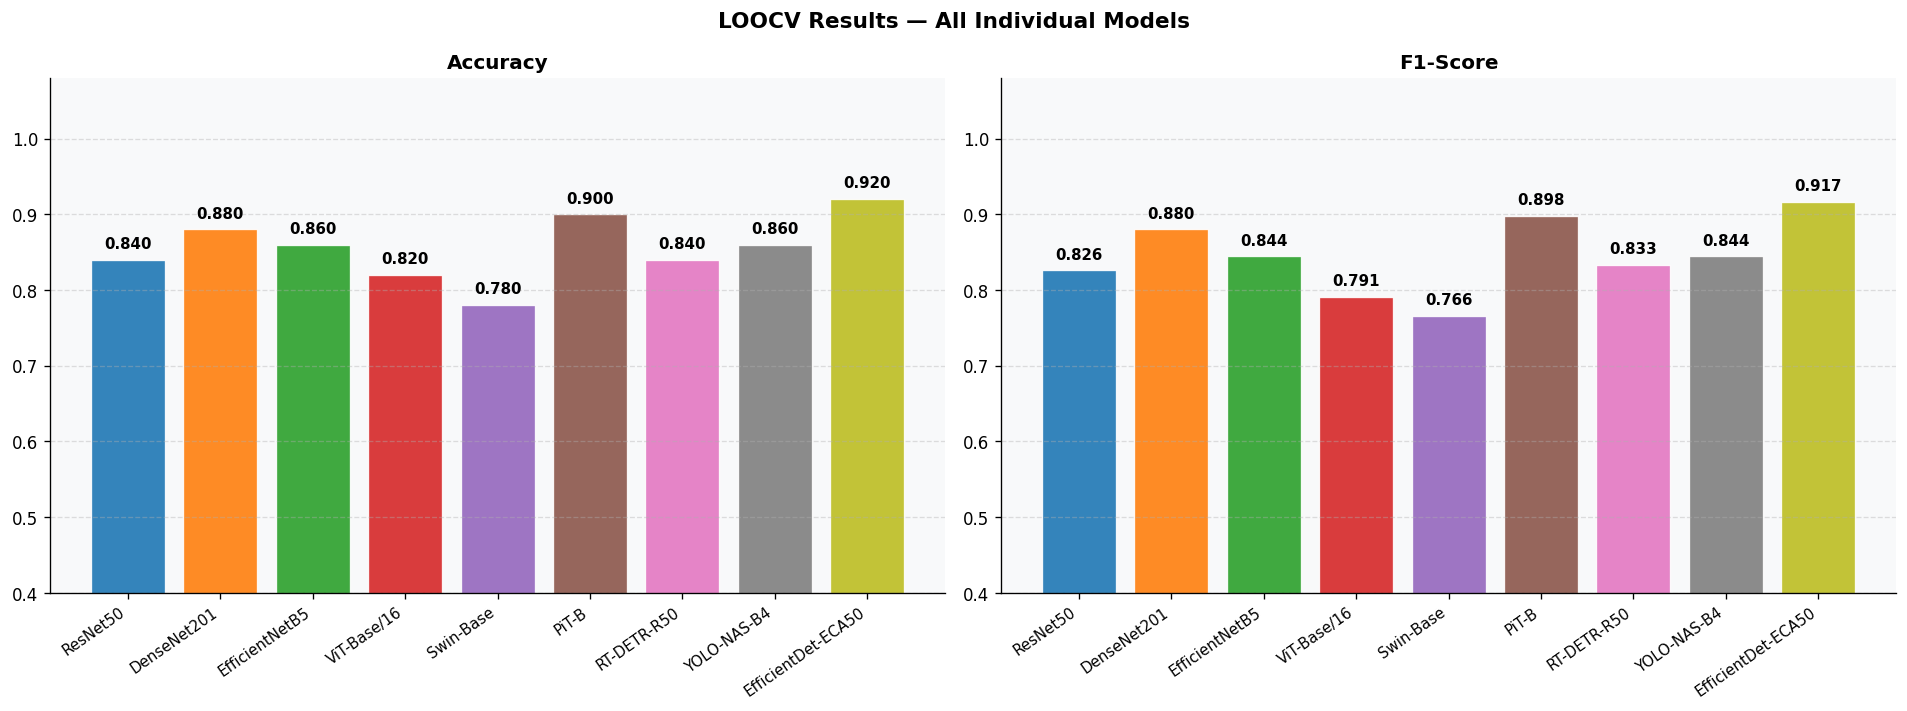

fig_loocv_all_models.png
Saved: loocv_results_all_models.csv


In [18]:
# ── LOOCV results — all models bar chart ──────────────────────────
loocv_names = [MODEL_DISPLAY[nm] for nm in ALL_NAMES]
loocv_accs  = [loocv_results[nm]['acc'] for nm in ALL_NAMES]
loocv_f1s   = [loocv_results[nm]['f1']  for nm in ALL_NAMES]

COLORS9 = plt.cm.tab10.colors[:len(ALL_NAMES)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LOOCV Results — All Individual Models', fontsize=13, fontweight='bold')

for ax, vals, title in [(axes[0], loocv_accs, 'Accuracy'),
                         (axes[1], loocv_f1s, 'F1-Score')]:
    bars = ax.bar(range(len(ALL_NAMES)), vals, color=COLORS9,
                  edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(ALL_NAMES)))
    ax.set_xticklabels(loocv_names, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0.40, 1.08)
    ax.set_title(title)
    ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_loocv_all_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("fig_loocv_all_models.png")

# Save LOOCV results to CSV
loocv_rows = []
for nm in ALL_NAMES:
    r = loocv_results[nm]
    loocv_rows.append({'model':nm, 'display':MODEL_DISPLAY[nm],
                       'n_samples':loocv_n, 'acc':r['acc'], 'prec':r['prec'],
                       'rec':r['rec'], 'f1':r['f1'], 'mcc':r['mcc']})
pd.DataFrame(loocv_rows).to_csv('loocv_results_all_models.csv', index=False)
print("Saved: loocv_results_all_models.csv")


## Results & CI

In [19]:
METRICS=['acc','prec','rec','f1','auc','mcc']

# Bootstrap CI
ci_table={}
for k in ALL_KEYS:
    row={}
    for m in METRICS:
        vals=[r[m] for r in mc[k]]
        mean,lo,hi=bootstrap_ci(vals)
        row[m]={'mean':mean,'lo':lo,'hi':hi,'std':float(np.std(vals))}
    ci_table[k]=row

print("\n"+"="*95)
print("  MC-CV RESULTS + 95% BOOTSTRAP CI")
print("="*95)
print(f"{'Model':<22} {'Accuracy':>22} {'Precision':>22} {'F1':>22} {'AUC':>22}")
print("-"*95)
for k in ALL_KEYS:
    r=ci_table[k]; name=MODEL_DISPLAY.get(k,k)
    def fmt(m): return f"{r[m]['mean']:.4f}[{r[m]['lo']:.3f},{r[m]['hi']:.3f}]"
    print(f"  {name:<20} {fmt('acc'):>24} {fmt('prec'):>24} {fmt('f1'):>24} {fmt('auc'):>24}")
print("="*95)

print(f"\n  LOOCV ({MODEL_DISPLAY[best_ind_nm]}): "
      f"Acc={loocv_acc:.4f}  Prec={loocv_prec:.4f}  "
      f"Rec={loocv_rec:.4f}  F1={loocv_f1:.4f}  MCC={loocv_mcc:.4f}")



  MC-CV RESULTS + 95% BOOTSTRAP CI
Model                                Accuracy              Precision                     F1                    AUC
-----------------------------------------------------------------------------------------------
  ResNet50                  0.9471[0.947,0.947]      0.9767[0.977,0.977]      0.9529[0.953,0.953]      0.9909[0.991,0.991]
  DenseNet201               0.9466[0.947,0.947]      0.9827[0.983,0.983]      0.9522[0.952,0.952]      0.9919[0.992,0.992]
  EfficientNetB5            0.9338[0.934,0.934]      0.9787[0.979,0.979]      0.9403[0.940,0.940]      0.9877[0.988,0.988]
  ViT-Base/16               0.9432[0.943,0.943]      0.9761[0.976,0.976]      0.9493[0.949,0.949]      0.9900[0.990,0.990]
  Swin-Base                 0.9440[0.944,0.944]      0.9852[0.985,0.985]      0.9496[0.950,0.950]      0.9928[0.993,0.993]
  PiT-B                     0.9373[0.937,0.937]      0.9789[0.979,0.979]      0.9436[0.944,0.944]      0.9904[0.990,0.990]
  RT-DETR-R50  

In [20]:
# ── Wilcoxon tests ─────────────────────────────────────────────────
from scipy.stats import wilcoxon
print("\n── Wilcoxon: HyConDViT-Net vs each individual model ────────")
hycd_accs=[r['acc'] for r in mc['hyconDvit_net']]
for nm in ALL_NAMES:
    ind=[r['acc'] for r in mc[nm]]
    try:
        w,p=wilcoxon(hycd_accs,ind,alternative='greater')
        sig='***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
        print(f"  {MODEL_DISPLAY[nm]:<22}: p={p:.4f} {sig}")
    except Exception as e:
        print(f"  {MODEL_DISPLAY[nm]:<22}: {e}")



── Wilcoxon: HyConDViT-Net vs each individual model ────────
  ResNet50              : p=0.5000 ns
  DenseNet201           : p=0.5000 ns
  EfficientNetB5        : p=0.5000 ns
  ViT-Base/16           : p=0.5000 ns
  Swin-Base             : p=0.5000 ns
  PiT-B                 : p=0.5000 ns
  RT-DETR-R50           : p=0.5000 ns
  YOLO-NAS-B4           : p=0.5000 ns
  EfficientDet-ECA50    : p=0.5000 ns


## Visualization Setup

In [21]:
# ── Rebuild models for visualization (MEMORY-EFFICIENT + DETERMINISTIC) ──
# FIX: the HyConDViT-Net ensemble is no longer RE-TRAINED here. Instead the
# winning ensemble persisted during MC-CV (learned alpha + calibrated
# threshold + the 9 fine-tuned constituent state-dicts) is reloaded exactly,
# so the visualization / external / KD / Grad-CAM stages evaluate the SAME
# ensemble that scored best during cross-validation. This eliminates the
# degenerate all-negative rebuild.
import os

# Recover the persisted ensemble (in-memory global, or disk backup).
if 'best_hyconDvit' not in globals() or best_hyconDvit.get('ft_states') is None:
    assert os.path.exists('best_hyconDvit.pt'), \
        "best_hyconDvit not found — run the MC-CV cell first."
    best_hyconDvit = torch.load('best_hyconDvit.pt', map_location='cpu', weights_only=False)
    print("Loaded persisted HyConDViT-Net from disk backup.")

_viz_seed = best_hyconDvit.get('seed', BASE_SEED)
set_seed(_viz_seed)
tr_viz, vl_viz, te_viz, cw_viz = get_loaders(_viz_seed)
print(f"Visualization split rebuilt from best run (seed={_viz_seed}, "
      f"persisted acc={best_hyconDvit['acc']:.4f}, "
      f"threshold={best_hyconDvit['threshold']:.3f})")

def to_device_list(models, device=DEVICE):
    return [m.to(device) for m in models]

def to_cpu_list(models):
    for m in models: m.cpu()
    torch.cuda.empty_cache(); gc.collect()

# ── Step 1: individual models — build, evaluate, store metrics, CPU ──
best_inst   = {}   # CPU-resident model objects (moved to GPU on demand)
ind_metrics = {}   # cached evaluation results

for nm in ALL_NAMES:
    m = build_model(nm, freeze=True).to(DEVICE)
    m.load_state_dict({k: v.to(DEVICE) for k, v in best_states[nm].items()})
    met = evaluate(m, te_viz)
    ind_metrics[nm] = met
    m.cpu()
    best_inst[nm] = m
    torch.cuda.empty_cache()
    print(f"  {nm:<22}: acc={met['acc']:.4f} prec={met['prec']:.4f} "
          f"f1={met['f1']:.4f}  (moved to CPU)")

gc.collect(); torch.cuda.empty_cache()
print(f"\nIndividual models done. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Step 2: reconstruct the 9 fine-tuned constituents from the PERSISTED
#    winning-run states (no re-fine-tuning — guarantees identity with MC-CV) ──
ft_viz = {}
for nm in ALL_NAMES:
    m = build_model(nm, freeze=True)
    m = unfreeze_last_block(m, nm)
    m.load_state_dict(best_hyconDvit['ft_states'][nm])  # exact weights + BN stats
    m.cpu().eval()
    ft_viz[nm] = m
    print(f"  {nm}: restored fine-tuned constituent (CPU).")

# ── Step 3: build + evaluate each ensemble, moving only what's needed ──
viz_ensembles  = []
ens_metrics    = {}

# CNN-Fusion (3 models)
_grp = to_device_list([ft_viz[n] for n in CNN_NAMES])
cnn_ens_v = SoftVoteEnsemble(_grp).to(DEVICE); cnn_ens_v.eval()
ens_metrics['CNN-Fusion'] = evaluate(cnn_ens_v, te_viz)
viz_ensembles.append(('CNN-Fusion', cnn_ens_v, '#3498DB', False))
to_cpu_list(_grp)
print(f"  CNN-Fusion   acc={ens_metrics['CNN-Fusion']['acc']:.4f}")

# Trans-Fusion (3 models)
_grp = to_device_list([ft_viz[n] for n in TRANS_NAMES])
trs_ens_v = SoftVoteEnsemble(_grp).to(DEVICE); trs_ens_v.eval()
ens_metrics['Trans-Fusion'] = evaluate(trs_ens_v, te_viz)
viz_ensembles.append(('Trans-Fusion', trs_ens_v, '#9B59B6', False))
to_cpu_list(_grp)
print(f"  Trans-Fusion acc={ens_metrics['Trans-Fusion']['acc']:.4f}")

# Det-Fusion (3 models)
_grp = to_device_list([ft_viz[n] for n in DET_NAMES])
det_ens_v = SoftVoteEnsemble(_grp).to(DEVICE); det_ens_v.eval()
ens_metrics['Det-Fusion'] = evaluate(det_ens_v, te_viz)
viz_ensembles.append(('Det-Fusion', det_ens_v, '#E67E22', False))
to_cpu_list(_grp)
print(f"  Det-Fusion   acc={ens_metrics['Det-Fusion']['acc']:.4f}")

# HyConViT-Net (6 models: CNN + Transformer)
_grp = to_device_list([ft_viz[n] for n in CNN_NAMES + TRANS_NAMES])
hyconvit_v = SoftVoteEnsemble(_grp).to(DEVICE); hyconvit_v.eval()
ens_metrics['HyConViT-Net'] = evaluate(hyconvit_v, te_viz)
viz_ensembles.append(('HyConViT-Net', hyconvit_v, '#1ABC9C', False))
to_cpu_list(_grp)
print(f"  HyConViT-Net acc={ens_metrics['HyConViT-Net']['acc']:.4f}")

# HyConDViT-Net (all 9) — RELOAD persisted alpha + threshold, NO re-training
_grp = to_device_list([ft_viz[n] for n in ALL_NAMES])
hyconDvit_v = HyConDViTNet(_grp, [MODEL_CONFIGS[n]['type'] for n in ALL_NAMES]).to(DEVICE)
hyconDvit_v.alpha.data       = best_hyconDvit['alpha'].to(DEVICE)   # trained weights
hyconDvit_v.learned_threshold = best_hyconDvit['threshold']          # calibrated threshold
hyconDvit_v.eval()
ens_metrics['HyConDViT-Net'] = evaluate_hyconDvit(hyconDvit_v, te_viz)
viz_ensembles.append(('HyConDViT-Net', hyconDvit_v, '#E74C3C', True))
to_cpu_list(_grp)   # constituents to CPU; downstream cells call .to(DEVICE)
_w = F.softmax(hyconDvit_v.alpha.detach(), dim=0).cpu().numpy()
print(f"  HyConDViT-Net acc={ens_metrics['HyConDViT-Net']['acc']:.4f} "
      f"rec={ens_metrics['HyConDViT-Net']['rec']:.4f}  "
      f"(RESTORED, not re-trained)")
print(f"    learned weights w=[{','.join(f'{x:.3f}' for x in _w)}]")

for label, ens, _, is_calib in viz_ensembles:
    met = ens_metrics[label]
    print(f"  {label:<16}: acc={met['acc']:.4f} prec={met['prec']:.4f} "
          f"rec={met['rec']:.4f} f1={met['f1']:.4f}")

print(f"\nAll ensembles restored + evaluated. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("NOTE: best_inst, ft_viz and ensemble constituents are CPU-resident;")
print("      downstream cells call .to(DEVICE) before use and .cpu() after.")


  Seed 42: train=41,240 | val=8,840 | test=8,840
  Originals split: 8,248/1,768/1,768 (each x5 aug copies)
Visualization split rebuilt from best run (seed=42, persisted acc=0.9708, threshold=0.360)
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : acc=0.9485 prec=0.9785 f1=0.9542  (moved to CPU)
  densenet201           : 2,235,906/20,328,834 (11.0%)  [densenet201]
  densenet201           : acc=0.9443 prec=0.9798 f1=0.9502  (moved to CPU)
  efficientnetb5        : 2,367,234/30,708,018 (7.7%)  [tf_efficientnet_b5]
  efficientnetb5        : acc=0.9370 prec=0.9805 f1=0.9432  (moved to CPU)
  vit_base              : 1,053,954/86,852,610 (1.2%)  [vit_base_patch16_224]
  vit_base              : acc=0.9442 prec=0.9756 f1=0.9503  (moved to CPU)
  swin_base             : 1,316,610/88,059,834 (1.5%)  [swin_base_patch4_window7_224]
  swin_base             : acc=0.9447 prec=0.9838 f1=0.9503  (moved to CPU)
  pit_base              : 1,316,610/74,056,450 (1.8

## Knowledge Distillation — HyConDViT-Net Teacher → Lightweight Student

**Motivation:** HyConDViT-Net (9-model ensemble) is accurate but expensive to deploy — 9 forward
passes per prediction. Knowledge Distillation compresses this into a **single lightweight student
model** that mimics the teacher's soft output distribution, aiming to retain most of the ensemble's
accuracy at a fraction of the inference cost.

**Method:**
$$\mathcal{L}_{KD} = \alpha \cdot \mathcal{L}_{CE}(y_{student}, y_{true}) + (1-\alpha) \cdot T^2 \cdot \mathcal{L}_{KL}\!\left(\sigma(z_{student}/T),\ \sigma(z_{teacher}/T)\right)$$

where $T$ is the distillation temperature (softens both distributions), $\alpha$ balances hard-label
and soft-label loss, and $z$ denotes pre-softmax logits.

**Teacher:** HyConDViT-Net (calibrated 9-model ensemble, already trained above)
**Student:** the smallest backbone in the registry — trained from scratch using KD loss only


In [22]:
# ── Knowledge Distillation: HyConDViT-Net Teacher -> Student ─────
KD_STUDENT_NAME = DET_NAMES[0]   # RT-DETR backbone (registry-driven; works for both notebooks)
KD_TEMPERATURE  = 4.0
KD_ALPHA        = 0.30           # weight on hard-label CE loss
KD_EPOCHS       = 15

print(f"KD Teacher : HyConDViT-Net (9-model ensemble, calibrated)")
print(f"KD Student : {MODEL_DISPLAY[KD_STUDENT_NAME]}")
print(f"KD Temp    : {KD_TEMPERATURE}  |  Alpha (hard-label weight): {KD_ALPHA}")
print(f"KD Epochs  : {KD_EPOCHS}")

class KDLoss(nn.Module):
    """Standard Hinton KD loss: alpha*CE + (1-alpha)*T^2*KL(student||teacher)."""
    def __init__(self, alpha=KD_ALPHA, T=KD_TEMPERATURE):
        super().__init__()
        self.alpha = alpha; self.T = T
        self.ce  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
        self.kld = nn.KLDivLoss(reduction='batchmean')

    def forward(self, student_logits, teacher_logits, targets):
        hard_loss = self.ce(student_logits, targets)
        soft_student = F.log_softmax(student_logits / self.T, dim=1)
        soft_teacher = F.softmax(teacher_logits / self.T, dim=1)
        soft_loss = self.kld(soft_student, soft_teacher) * (self.T ** 2)
        return self.alpha * hard_loss + (1 - self.alpha) * soft_loss

# ── Build fresh student model (frozen backbone, trainable head) ──
kd_student = build_model(KD_STUDENT_NAME, freeze=True).to(DEVICE)
kd_opt  = optim.AdamW(kd_student.head.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
kd_crit = KDLoss()
kd_sc   = GradScaler()

# Teacher: move only what's needed for HyConDViT-Net back to GPU
_teacher_models = to_device_list([ft_viz[n] for n in ALL_NAMES])
kd_teacher = HyConDViTNet(_teacher_models, [MODEL_CONFIGS[n]['type'] for n in ALL_NAMES]).to(DEVICE)
kd_teacher.alpha.data = hyconDvit_v.alpha.data.clone()
kd_teacher.learned_threshold = hyconDvit_v.learned_threshold
kd_teacher.eval()

print("\nTraining student via distillation...")
kd_hist = {'loss': [], 'val_acc': []}
for ep in range(1, KD_EPOCHS+1):
    kd_student.train(); kd_student.backbone.eval()
    ep_loss = 0.0; n_samp = 0
    for imgs, lbls in tr_viz:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        with torch.no_grad():
            teacher_probs = torch.exp(kd_teacher(imgs))   # HyConDViTNet returns log-probs
            teacher_logits = torch.log(teacher_probs + 1e-8)  # pseudo-logits for KD loss

        kd_opt.zero_grad()
        with autocast():
            student_logits = kd_student(imgs)
            loss = kd_crit(student_logits, teacher_logits, lbls)
        kd_sc.scale(loss).backward()
        kd_sc.step(kd_opt); kd_sc.update()
        ep_loss += loss.item() * imgs.size(0); n_samp += imgs.size(0)

    kd_met = evaluate(kd_student, vl_viz)
    kd_hist['loss'].append(ep_loss/n_samp); kd_hist['val_acc'].append(kd_met['acc'])
    if ep % 3 == 0 or ep == 1:
        print(f"  Ep {ep:>2}/{KD_EPOCHS}  loss={ep_loss/n_samp:.4f}  val_acc={kd_met['acc']:.4f}")

kd_test_met = evaluate(kd_student, te_viz)
print(f"\n✅ Student ({MODEL_DISPLAY[KD_STUDENT_NAME]}) distilled.")
print(f"  Student TEST : acc={kd_test_met['acc']:.4f}  prec={kd_test_met['prec']:.4f}  "
      f"rec={kd_test_met['rec']:.4f}  f1={kd_test_met['f1']:.4f}  auc={kd_test_met['auc']:.4f}")

# Compare vs standalone (non-distilled) same-architecture model & full teacher
baseline_acc = np.mean([r['acc'] for r in mc[KD_STUDENT_NAME]])
teacher_acc  = ens_metrics['HyConDViT-Net']['acc']
print(f"\n  Standalone {MODEL_DISPLAY[KD_STUDENT_NAME]} (no KD, MC-CV mean): {baseline_acc:.4f}")
print(f"  Distilled  {MODEL_DISPLAY[KD_STUDENT_NAME]} (with KD)           : {kd_test_met['acc']:.4f}")
print(f"  Teacher    HyConDViT-Net (9-model ensemble)                    : {teacher_acc:.4f}")
print(f"  KD gain over standalone : {kd_test_met['acc']-baseline_acc:+.4f}")
print(f"  Gap to teacher          : {teacher_acc-kd_test_met['acc']:+.4f}")
print(f"  Compression             : 1 model vs 9 models (~9x fewer forward passes)")

kd_student.cpu(); to_cpu_list(_teacher_models)
del kd_teacher
torch.cuda.empty_cache(); gc.collect()


KD Teacher : HyConDViT-Net (9-model ensemble, calibrated)
KD Student : RT-DETR-R50
KD Temp    : 4.0  |  Alpha (hard-label weight): 0.3
KD Epochs  : 15
  rtdetr_r50            : 2,367,234/25,894,498 (9.1%)  [resnet50d]

Training student via distillation...
  Ep  1/15  loss=0.1638  val_acc=0.9377
  Ep  3/15  loss=0.1417  val_acc=0.9452
  Ep  6/15  loss=0.1354  val_acc=0.9508
  Ep  9/15  loss=0.1329  val_acc=0.9531
  Ep 12/15  loss=0.1305  val_acc=0.9526
  Ep 15/15  loss=0.1299  val_acc=0.9538

✅ Student (RT-DETR-R50) distilled.
  Student TEST : acc=0.9532  prec=0.9797  rec=0.9381  f1=0.9585  auc=0.9935

  Standalone RT-DETR-R50 (no KD, MC-CV mean): 0.9511
  Distilled  RT-DETR-R50 (with KD)           : 0.9532
  Teacher    HyConDViT-Net (9-model ensemble)                    : 0.9724
  KD gain over standalone : +0.0020
  Gap to teacher          : +0.0192
  Compression             : 1 model vs 9 models (~9x fewer forward passes)


0

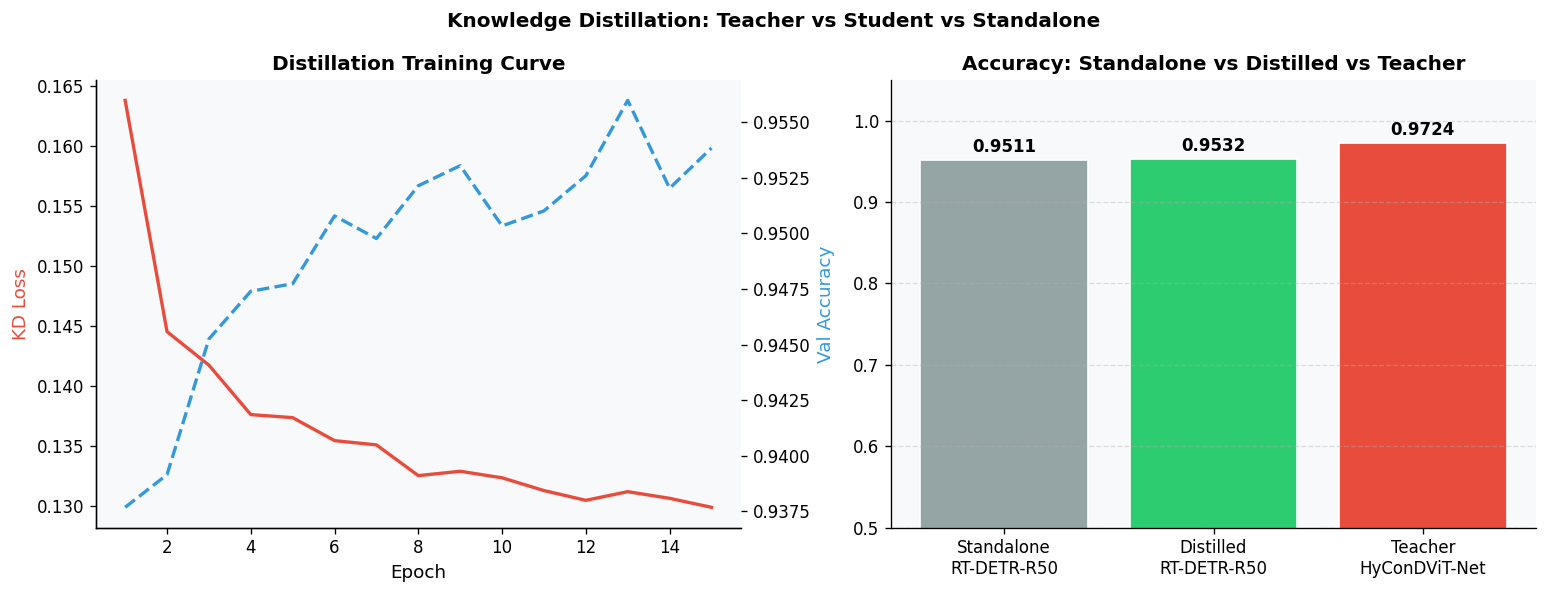

fig_kd_comparison.png
Saved: kd_results.csv


In [23]:
# ── KD comparison figure ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Knowledge Distillation: Teacher vs Student vs Standalone',
             fontsize=12, fontweight='bold')

# Training curve
axes[0].plot(range(1, len(kd_hist['loss'])+1), kd_hist['loss'],
             color='#E74C3C', linewidth=2, label='KD Loss')
ax2 = axes[0].twinx()
ax2.plot(range(1, len(kd_hist['val_acc'])+1), kd_hist['val_acc'],
          color='#3498DB', linewidth=2, linestyle='--', label='Val Acc')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('KD Loss', color='#E74C3C')
ax2.set_ylabel('Val Accuracy', color='#3498DB')
axes[0].set_title('Distillation Training Curve')
axes[0].set_facecolor('#F8F9FA')

# Comparison bar
comparison = {
    f'Standalone\n{MODEL_DISPLAY[KD_STUDENT_NAME]}': baseline_acc,
    f'Distilled\n{MODEL_DISPLAY[KD_STUDENT_NAME]}':  kd_test_met['acc'],
    'Teacher\nHyConDViT-Net': teacher_acc,
}
bars = axes[1].bar(comparison.keys(), comparison.values(),
                    color=['#95A5A6', '#2ECC71', '#E74C3C'],
                    edgecolor='white', linewidth=1)
for bar, v in zip(bars, comparison.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0.5, 1.05)
axes[1].set_title('Accuracy: Standalone vs Distilled vs Teacher')
axes[1].set_facecolor('#F8F9FA'); axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_kd_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("fig_kd_comparison.png")

# Save KD results
kd_summary = pd.DataFrame([{
    'student_model': KD_STUDENT_NAME,
    'standalone_acc': baseline_acc,
    'distilled_acc': kd_test_met['acc'],
    'teacher_acc': teacher_acc,
    'kd_gain': kd_test_met['acc'] - baseline_acc,
    'gap_to_teacher': teacher_acc - kd_test_met['acc'],
    'temperature': KD_TEMPERATURE,
    'alpha': KD_ALPHA,
}])
kd_summary.to_csv('kd_results.csv', index=False)
print("Saved: kd_results.csv")


## Fig 6: Results Heatmap

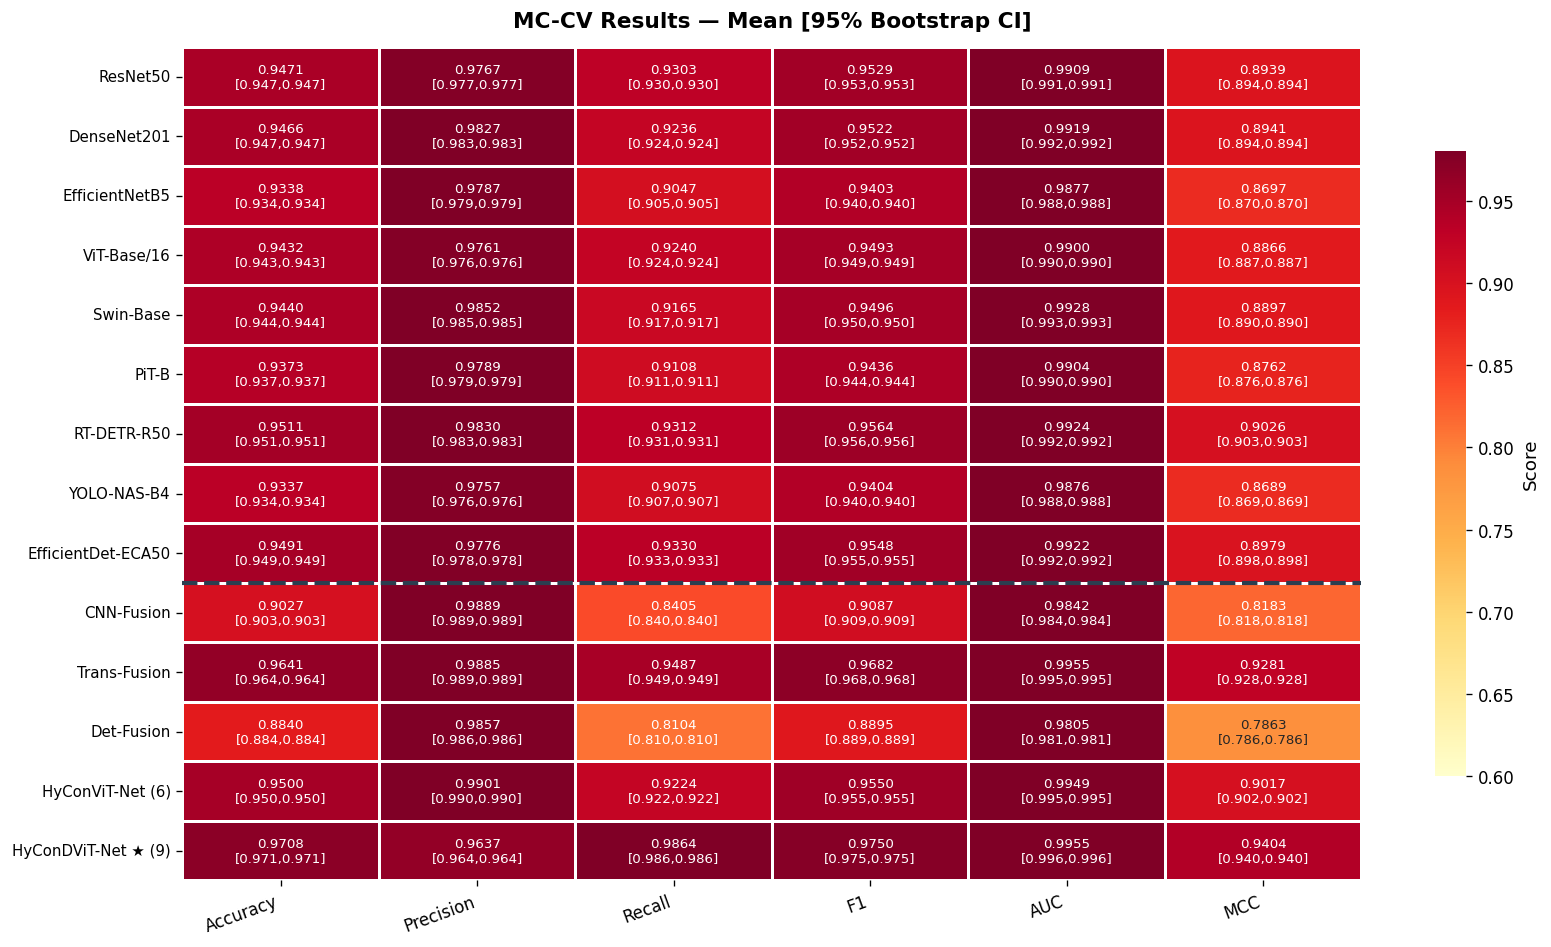

fig06_results_heatmap.png


In [24]:
# ── Fig 6: Results Heatmap ─────────────────────────────────────────
heat_means=[[ci_table[k][m]['mean'] for m in METRICS] for k in ALL_KEYS]
heat_df=pd.DataFrame(heat_means,
    index=[MODEL_DISPLAY.get(k,k) for k in ALL_KEYS],
    columns=['Accuracy','Precision','Recall','F1','AUC','MCC'])
ann_df=pd.DataFrame(
    [[f"{ci_table[k][m]['mean']:.4f}\n[{ci_table[k][m]['lo']:.3f},{ci_table[k][m]['hi']:.3f}]"
      for m in METRICS] for k in ALL_KEYS],
    index=heat_df.index, columns=heat_df.columns)

COLORS9=['#E74C3C','#3498DB','#2ECC71','#9B59B6','#F39C12','#1ABC9C',
         '#E67E22','#8E44AD','#16A085']
COLORS_ALL=COLORS9+['#3498DB','#9B59B6','#E67E22','#1ABC9C','#E74C3C']

fig,ax=plt.subplots(figsize=(14,8))
sns.heatmap(heat_df,annot=ann_df,fmt='',cmap='YlOrRd',
            vmin=0.60,vmax=0.98,linewidths=0.7,linecolor='white',ax=ax,
            cbar_kws={'label':'Score','shrink':0.75},annot_kws={'size':8})
ax.axhline(len(ALL_NAMES),color='#2C3E50',linewidth=2.5,linestyle='--')
ax.set_title('MC-CV Results — Mean [95% Bootstrap CI]',fontsize=13,fontweight='bold',pad=12)
ax.set_xticklabels(ax.get_xticklabels(),rotation=20,ha='right',fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=9)
plt.tight_layout()
plt.savefig('fig06_results_heatmap.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig06_results_heatmap.png")


## Fig 7: Confusion Matrices — Individual

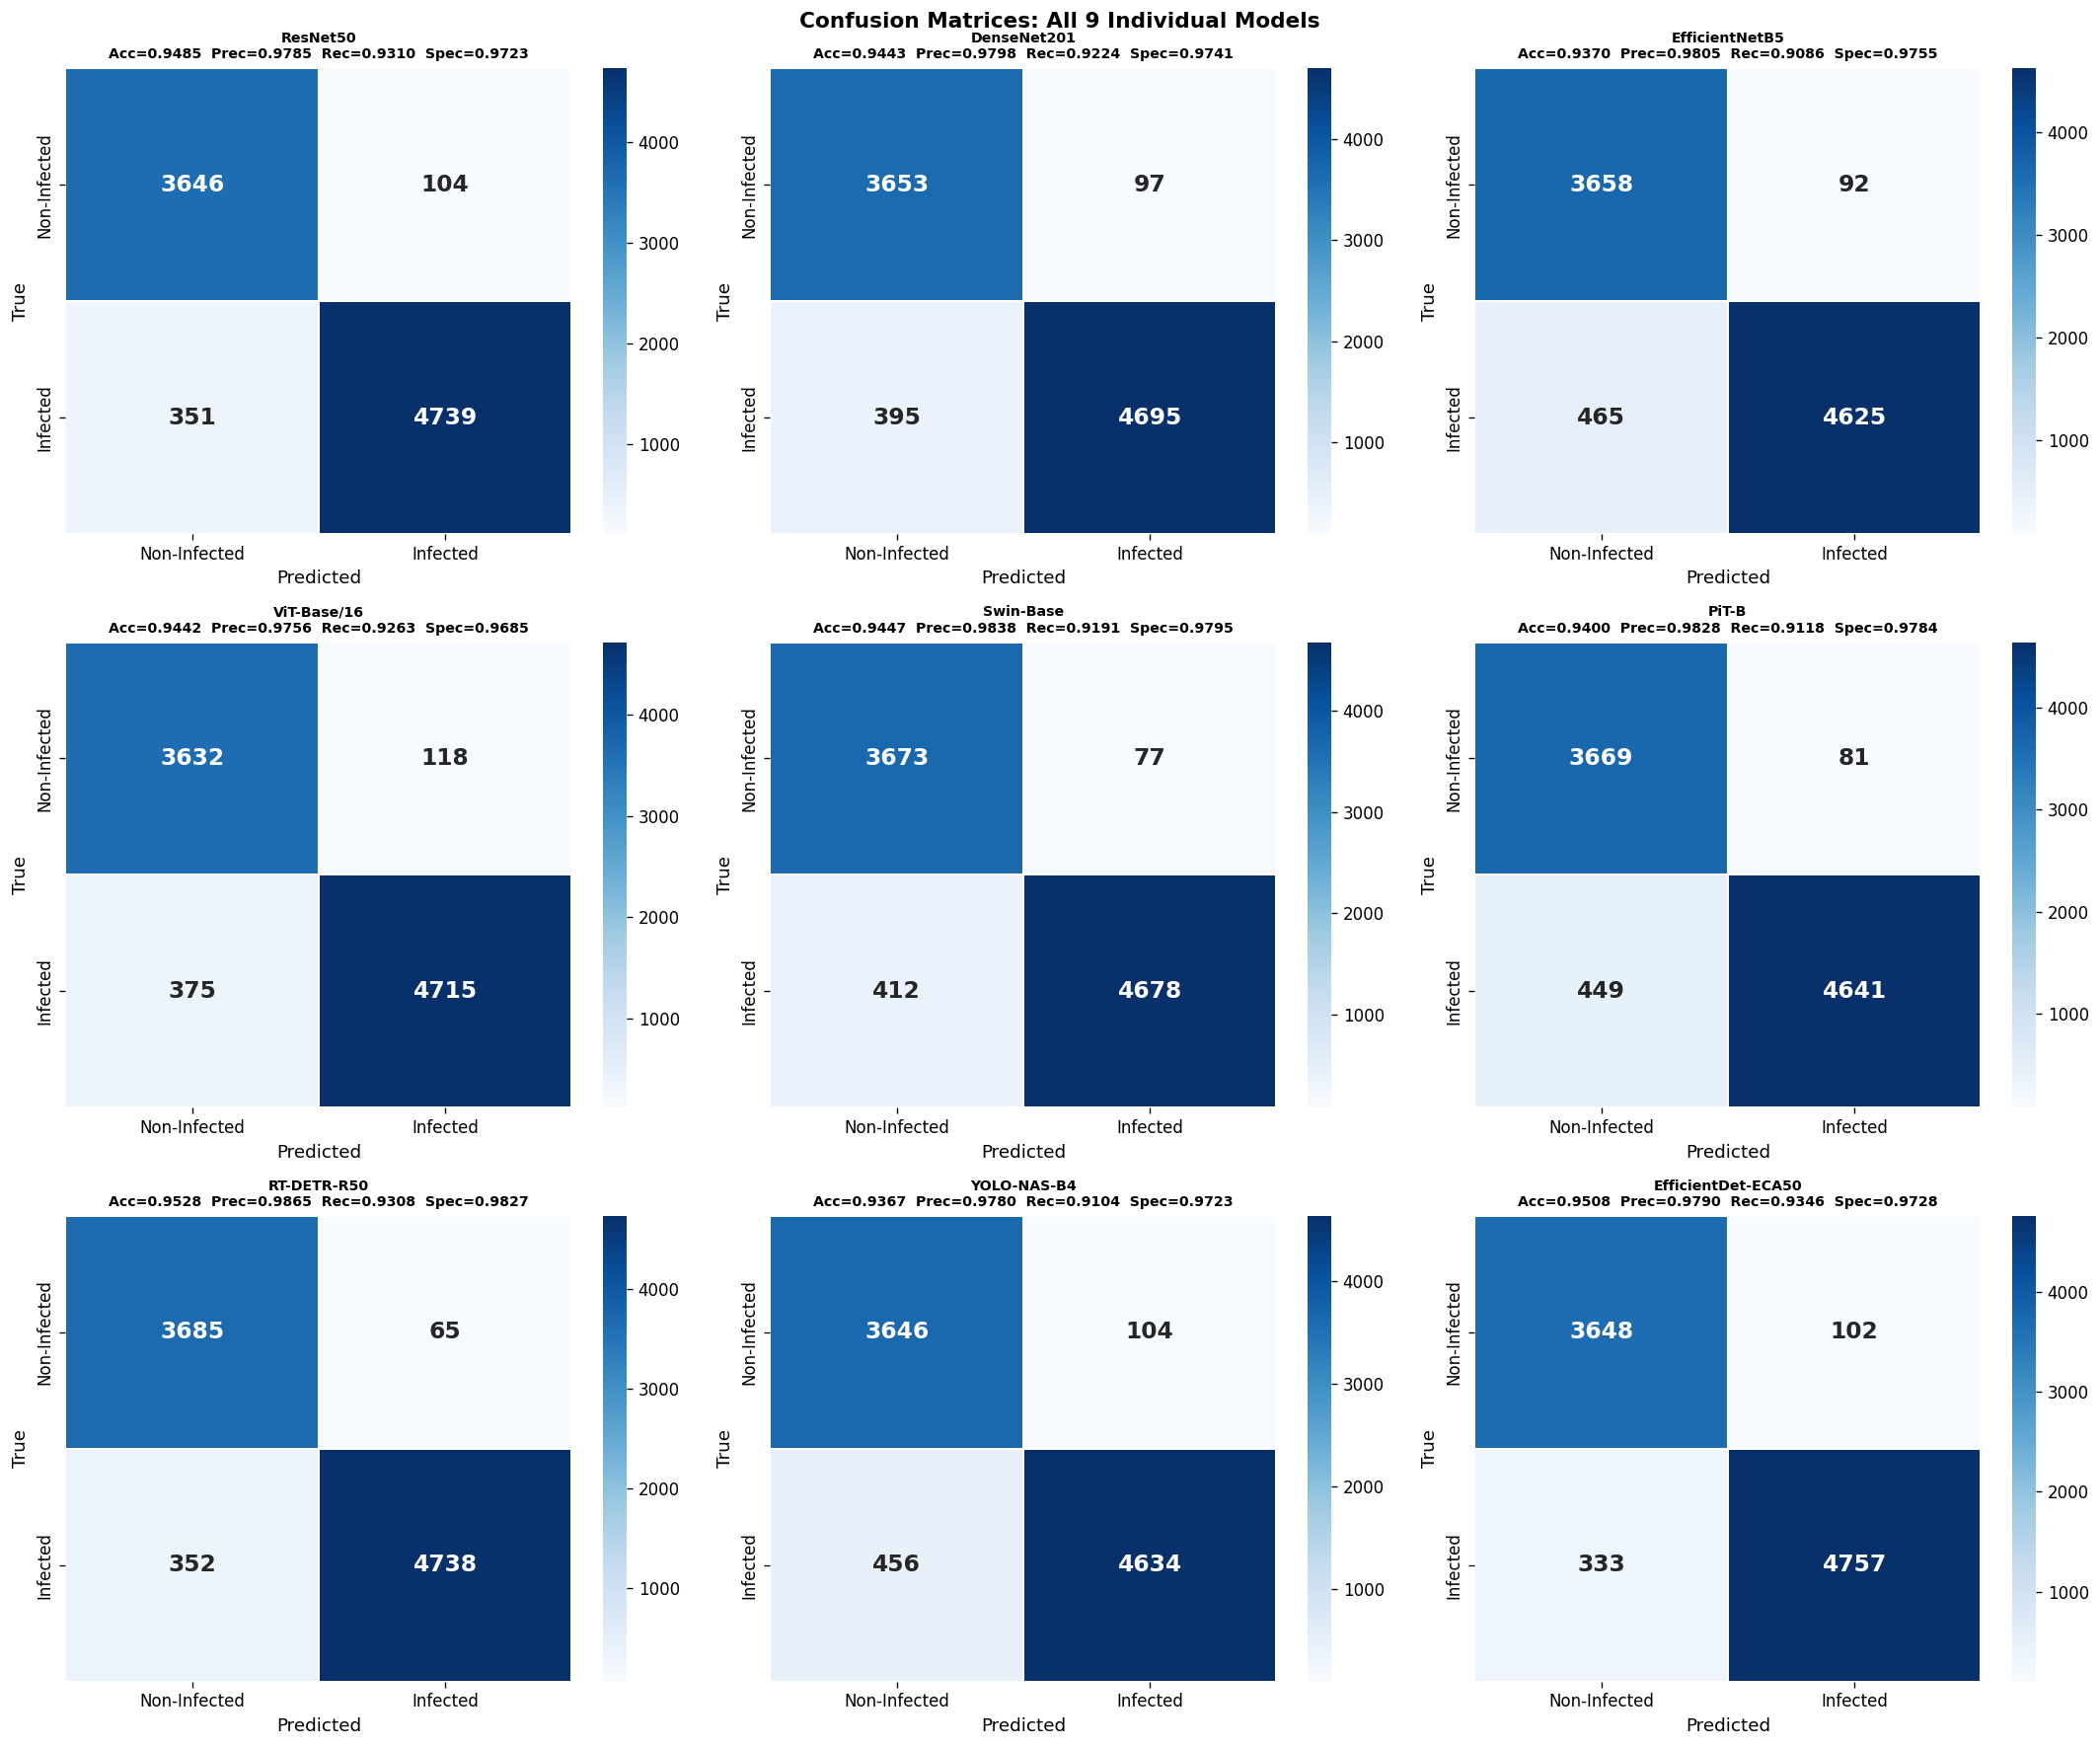

fig07_cm_individual.png


In [25]:
# ── Fig 7: Confusion Matrices — Individual Models ──────────────────
class_names=['Non-Infected','Infected']
fig,axes=plt.subplots(3,3,figsize=(18,15))
fig.suptitle('Confusion Matrices: All 9 Individual Models',fontsize=13,fontweight='bold')
for ax,nm in zip(axes.flat,ALL_NAMES):
    met=ind_metrics[nm]  # cached — no GPU needed
    cm=confusion_matrix(met['labels'],met['preds'])
    tn,fp,fn,tp=cm.ravel()
    spec=tn/(tn+fp) if (tn+fp)>0 else 0
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=class_names,yticklabels=class_names,
                linewidths=1.0,linecolor='white',
                annot_kws={'size':14,'weight':'bold'})
    ax.set_title(f"{MODEL_DISPLAY[nm]}\n"
                 f"Acc={met['acc']:.4f}  Prec={met['prec']:.4f}  "
                 f"Rec={met['rec']:.4f}  Spec={spec:.4f}",fontsize=8.5,pad=6)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('fig07_cm_individual.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig07_cm_individual.png")


## Fig 8: Confusion Matrices — Hybrid

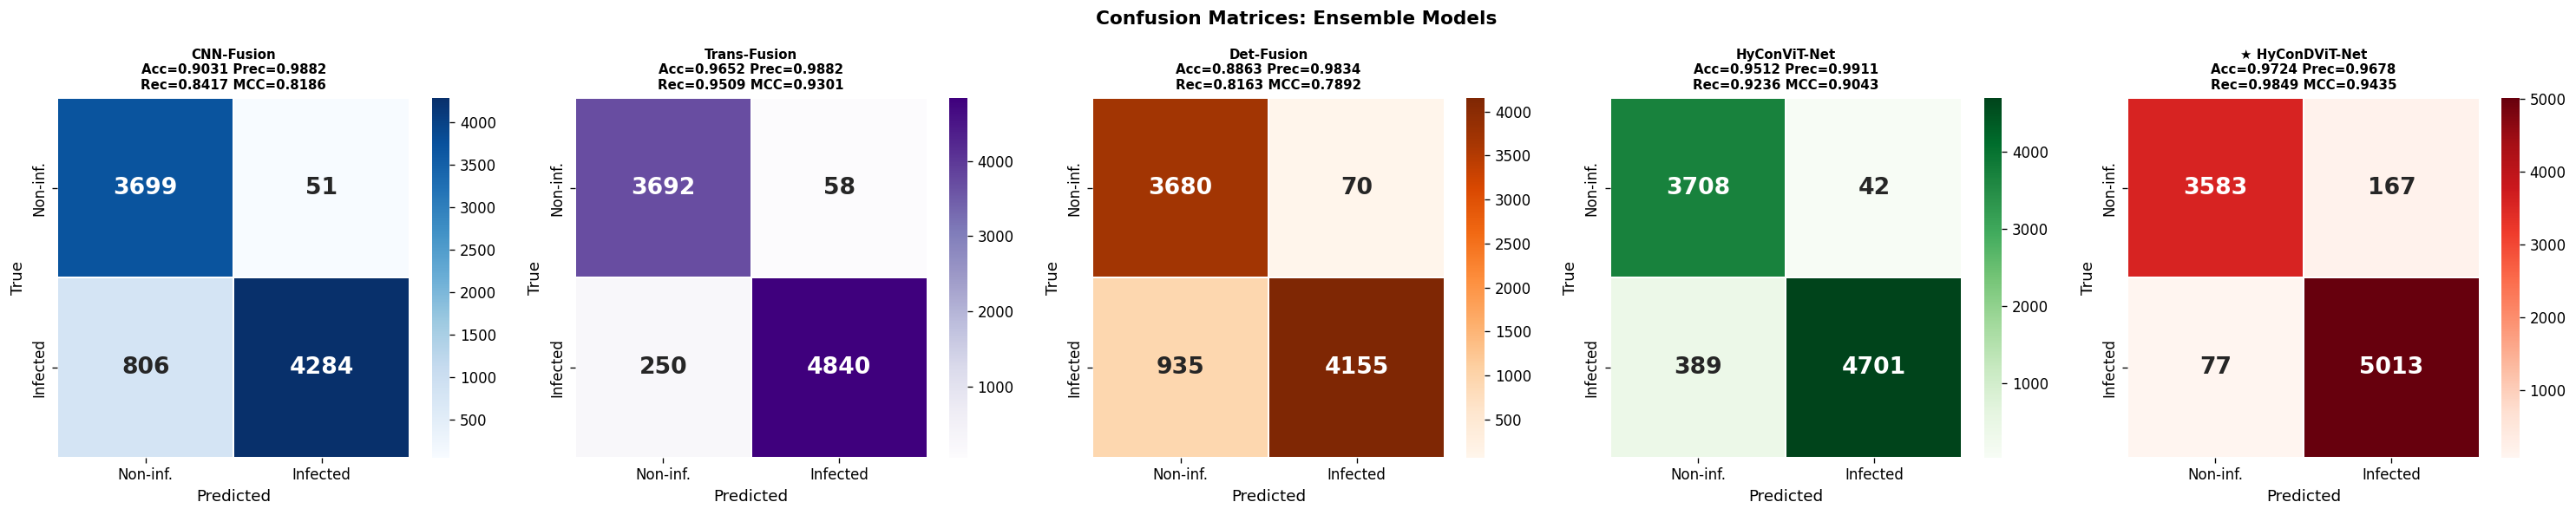

fig08_cm_hybrid.png


In [26]:
# ── Fig 8: Confusion Matrices — Hybrid Models ─────────────────────
fig,axes=plt.subplots(1,5,figsize=(25,5))
fig.suptitle('Confusion Matrices: Ensemble Models',fontsize=13,fontweight='bold')
cmaps=['Blues','Purples','Oranges','Greens','Reds']
for ax,(label,ens,col,is_calib),cmap in zip(axes,viz_ensembles,cmaps):
    met=ens_metrics[label]
    cm=confusion_matrix(met['labels'],met['preds'])
    tn,fp,fn,tp=cm.ravel(); spec=tn/(tn+fp) if (tn+fp)>0 else 0
    sns.heatmap(cm,annot=True,fmt='d',cmap=cmap,ax=ax,
                xticklabels=['Non-inf.','Infected'],
                yticklabels=['Non-inf.','Infected'],
                linewidths=1.0,linecolor='white',
                annot_kws={'size':16,'weight':'bold'})
    star='★ ' if 'HyConDViT' in label else ''
    ax.set_title(f"{star}{label}\nAcc={met['acc']:.4f} Prec={met['prec']:.4f}\n"
                 f"Rec={met['rec']:.4f} MCC={met['mcc']:.4f}",fontsize=9,pad=6)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('fig08_cm_hybrid.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig08_cm_hybrid.png")


## Fig 9: ROC Curves

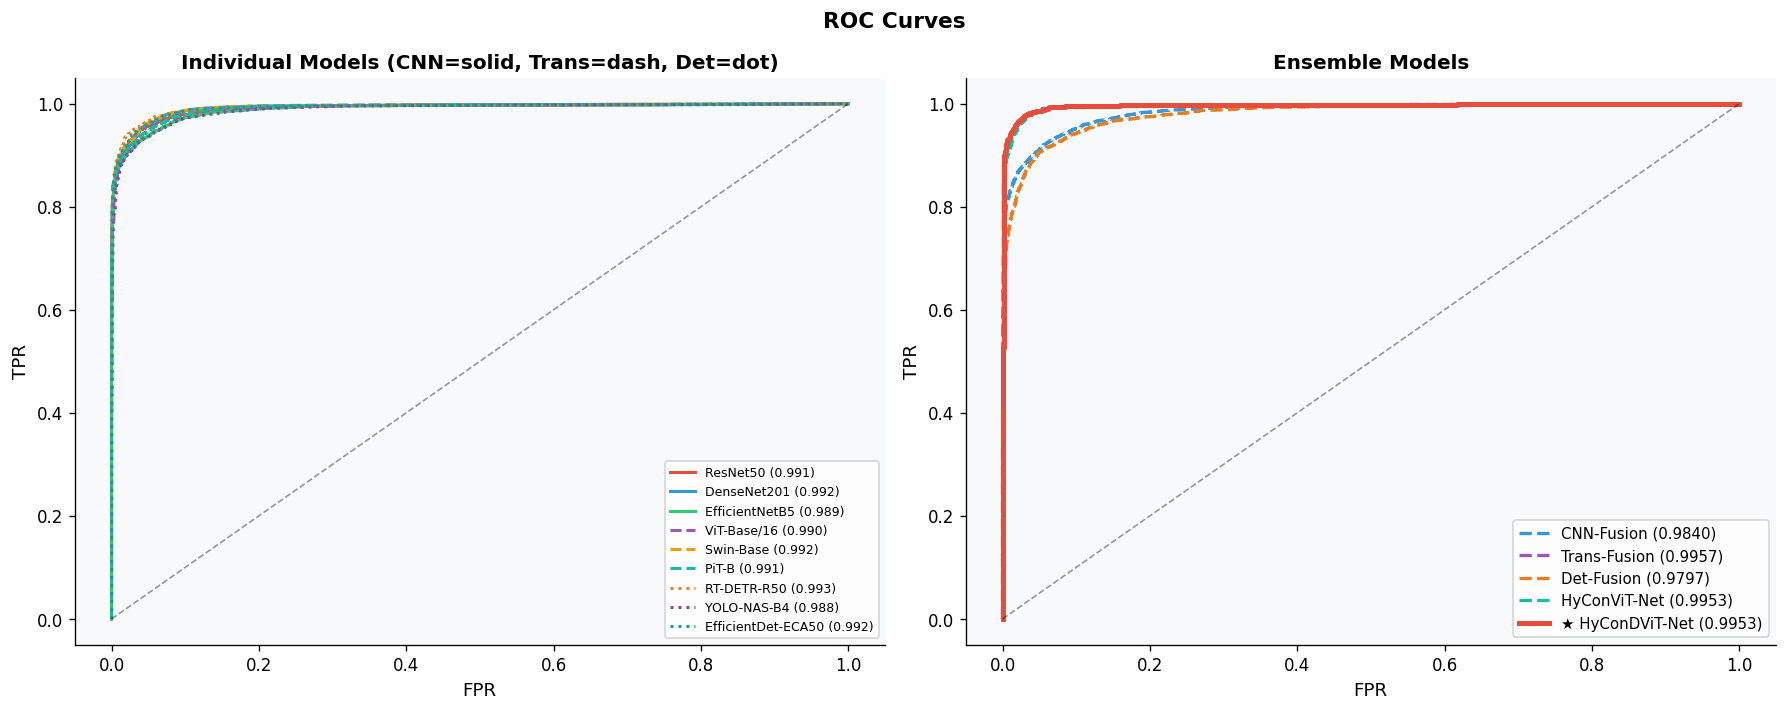

fig09_roc_curves.png


In [27]:
# ── Fig 9: ROC Curves ──────────────────────────────────────────────
ens_cols={'CNN-Fusion':'#3498DB','Trans-Fusion':'#9B59B6',
          'Det-Fusion':'#E67E22','HyConViT-Net':'#1ABC9C','HyConDViT-Net':'#E74C3C'}

fig,axes=plt.subplots(1,2,figsize=(15,6))
fig.suptitle('ROC Curves',fontsize=13,fontweight='bold')

ax=axes[0]
for nm,col in zip(ALL_NAMES,COLORS9):
    met=ind_metrics[nm]  # cached — no GPU needed
    fpr,tpr,_=roc_curve(met['labels'],met['probs'])
    ls='-' if MODEL_CONFIGS[nm]['type']=='CNN' else ('--' if MODEL_CONFIGS[nm]['type']=='Transformer' else ':')
    ax.plot(fpr,tpr,color=col,linewidth=1.8,linestyle=ls,
            label=f"{MODEL_DISPLAY[nm]} ({met['auc']:.3f})")
ax.plot([0,1],[0,1],'k--',linewidth=1,alpha=0.4)
ax.set_xlabel('FPR',fontsize=11); ax.set_ylabel('TPR',fontsize=11)
ax.set_title('Individual Models (CNN=solid, Trans=dash, Det=dot)')
ax.legend(fontsize=7.5,loc='lower right'); ax.set_facecolor('#F8F9FA')

ax=axes[1]
for label,ens,_,is_calib in viz_ensembles:
    met=ens_metrics[label]
    _lbl=np.asarray(met['labels']); _pr=np.nan_to_num(np.asarray(met['probs'],dtype=float),
                                                        nan=0.5,posinf=1.0,neginf=0.0)
    fpr,tpr,_=roc_curve(_lbl,_pr)
    lw=3.0 if 'HyConDViT' in label else 2.0
    ax.plot(fpr,tpr,color=ens_cols[label],linewidth=lw,
            linestyle='-' if 'HyConDViT' in label else '--',
            label=f"{'★ ' if 'HyConDViT' in label else ''}{label} ({met['auc']:.4f})")
ax.plot([0,1],[0,1],'k--',linewidth=1,alpha=0.4)
ax.set_xlabel('FPR',fontsize=11); ax.set_ylabel('TPR',fontsize=11)
ax.set_title('Ensemble Models'); ax.legend(fontsize=9); ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.savefig('fig09_roc_curves.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig09_roc_curves.png")


## Fig 10: PR Curves

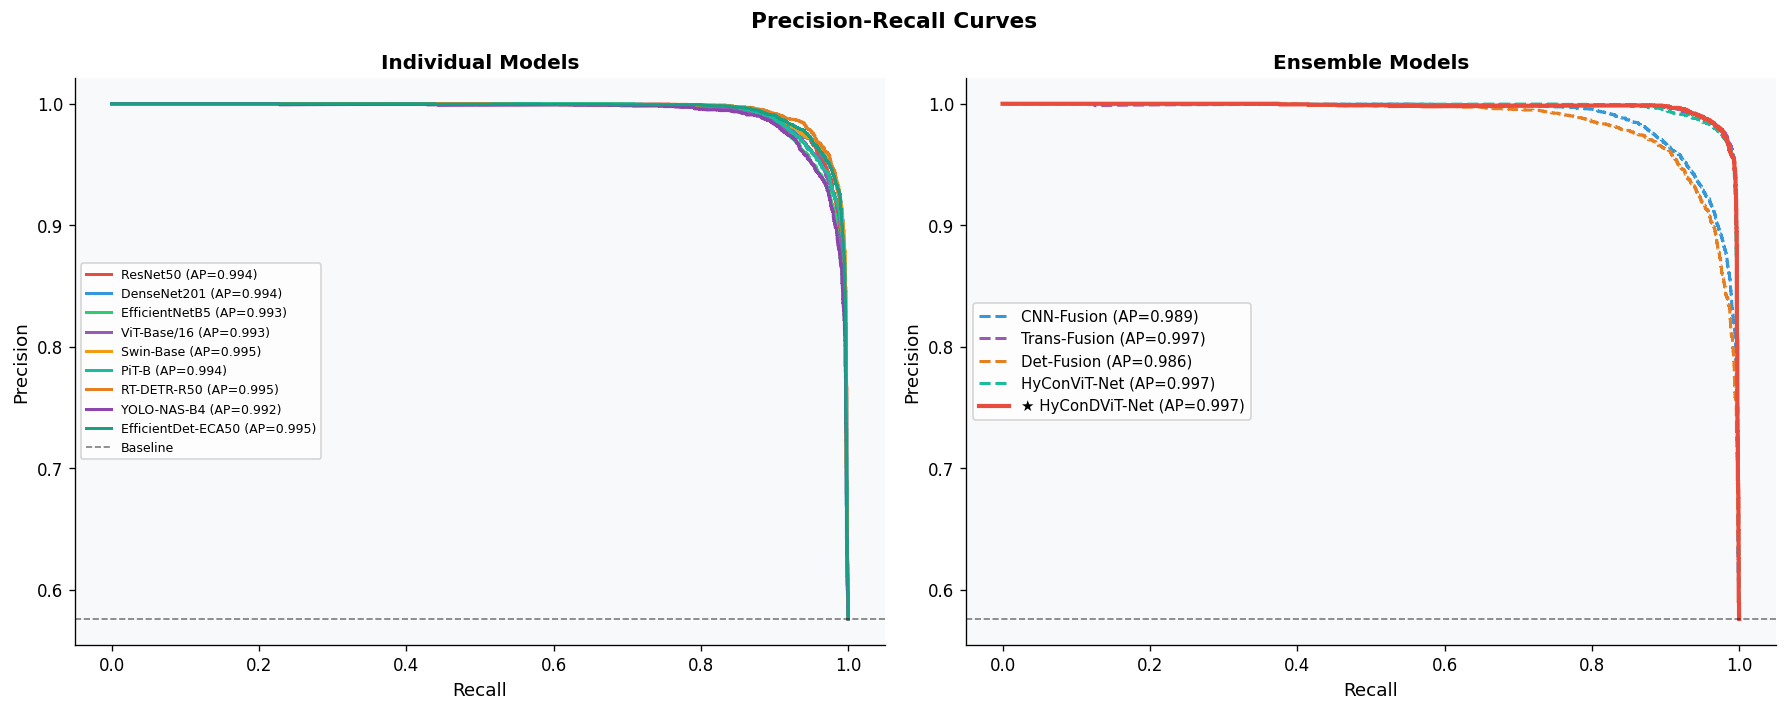

fig10_pr_curves.png


In [28]:
# ── Fig 10: Precision-Recall Curves ────────────────────────────────
baseline=sum(1 for x in te_viz.dataset.df['label'].values if x==1)/len(te_viz.dataset)

fig,axes=plt.subplots(1,2,figsize=(15,6))
fig.suptitle('Precision-Recall Curves',fontsize=13,fontweight='bold')

ax=axes[0]
for nm,col in zip(ALL_NAMES,COLORS9):
    met=ind_metrics[nm]  # cached — no GPU needed
    p,r,_=precision_recall_curve(met['labels'],met['probs'])
    ax.plot(r,p,color=col,linewidth=1.8,
            label=f"{MODEL_DISPLAY[nm]} (AP={met['ap']:.3f})")
ax.axhline(baseline,color='k',linestyle='--',linewidth=1,alpha=0.5,label='Baseline')
ax.set_xlabel('Recall',fontsize=11); ax.set_ylabel('Precision',fontsize=11)
ax.set_title('Individual Models'); ax.legend(fontsize=7.5); ax.set_facecolor('#F8F9FA')

ax=axes[1]
for label,ens,_,is_calib in viz_ensembles:
    met=ens_metrics[label]
    _lbl=np.asarray(met['labels']); _pr=np.nan_to_num(np.asarray(met['probs'],dtype=float),
                                                        nan=0.5,posinf=1.0,neginf=0.0)
    p,r,_=precision_recall_curve(_lbl,_pr)
    lw=2.5 if 'HyConDViT' in label else 1.8
    ax.plot(r,p,color=ens_cols[label],linewidth=lw,
            linestyle='-' if 'HyConDViT' in label else '--',
            label=f"{'★ ' if 'HyConDViT' in label else ''}{label} (AP={met['ap']:.3f})")
ax.axhline(baseline,color='k',linestyle='--',linewidth=1,alpha=0.5)
ax.set_xlabel('Recall',fontsize=11); ax.set_ylabel('Precision',fontsize=11)
ax.set_title('Ensemble Models'); ax.legend(fontsize=9); ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.savefig('fig10_pr_curves.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig10_pr_curves.png")


## Fig 11: Threshold Sensitivity

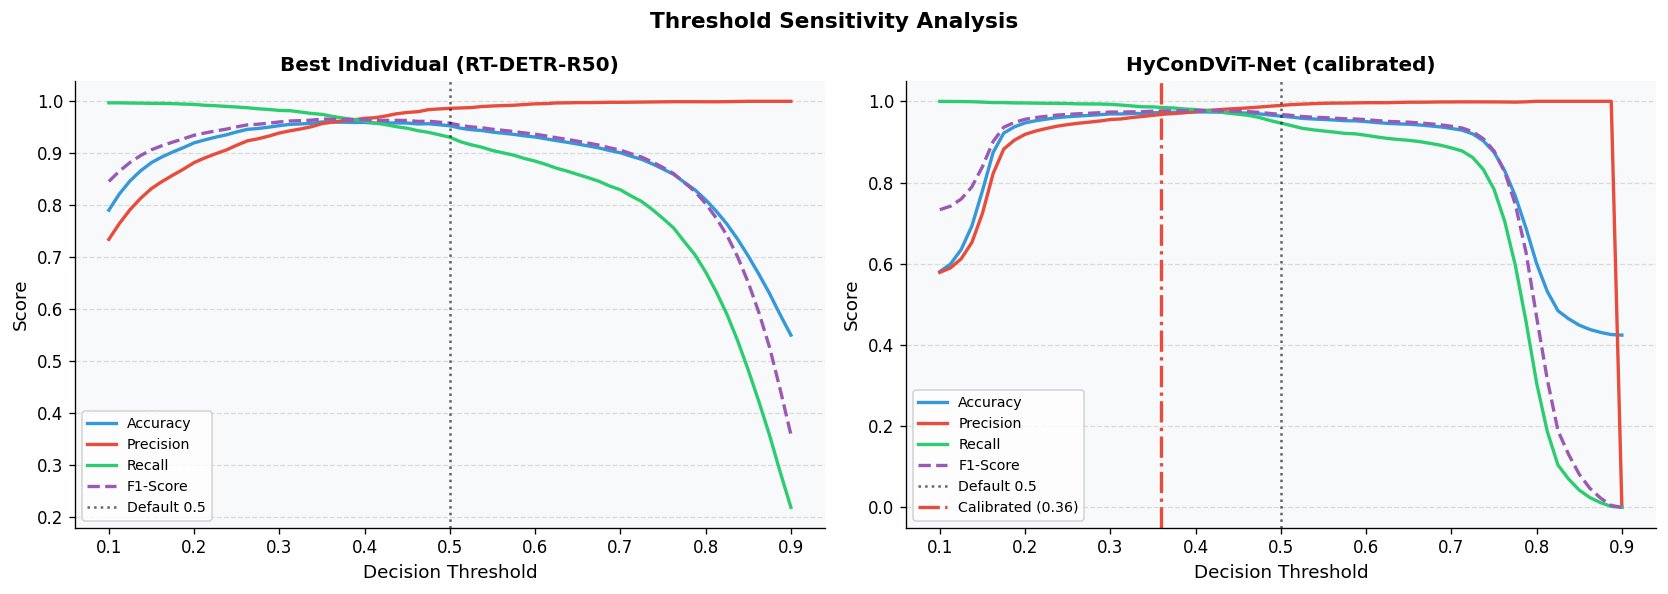

fig11_threshold_sensitivity.png


In [29]:
# ── Fig 11: Threshold Sensitivity ──────────────────────────────────
fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Threshold Sensitivity Analysis',fontsize=13,fontweight='bold')
thresholds=np.linspace(0.10,0.90,65)

best_ind_name=max(ALL_NAMES,key=lambda n:ci_table[n]['acc']['mean'])
for ax_idx,(name,met) in enumerate([
    (f'Best Individual ({MODEL_DISPLAY[best_ind_name]})',
     ind_metrics[best_ind_name]),  # cached — no GPU needed
    ('HyConDViT-Net (calibrated)', ens_metrics['HyConDViT-Net'])
]):
    ax=axes[ax_idx]
    pa=np.array(met['probs']); la=np.array(met['labels'])
    accs,precs,recs,f1s=[],[],[],[]
    for t in thresholds:
        p=(pa>=t).astype(int)
        accs.append(accuracy_score(la,p))
        precs.append(precision_score(la,p,zero_division=0))
        recs.append(recall_score(la,p,zero_division=0))
        f1s.append(f1_score(la,p,zero_division=0))
    ax.plot(thresholds,accs, label='Accuracy', color='#3498DB',linewidth=2)
    ax.plot(thresholds,precs,label='Precision',color='#E74C3C',linewidth=2)
    ax.plot(thresholds,recs, label='Recall',   color='#2ECC71',linewidth=2)
    ax.plot(thresholds,f1s,  label='F1-Score', color='#9B59B6',linewidth=2,linestyle='--')
    ax.axvline(0.5,color='k',linestyle=':',linewidth=1.5,alpha=0.6,label='Default 0.5')
    if ax_idx==1 and hasattr(hyconDvit_v,'learned_threshold'):
        ax.axvline(hyconDvit_v.learned_threshold,color='#E74C3C',linestyle='-.',
                   linewidth=2,label=f"Calibrated ({hyconDvit_v.learned_threshold:.2f})")
    ax.set_xlabel('Decision Threshold',fontsize=11); ax.set_ylabel('Score',fontsize=11)
    ax.set_title(name); ax.legend(fontsize=8.5)
    ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,linestyle='--',alpha=0.4)
plt.tight_layout()
plt.savefig('fig11_threshold_sensitivity.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig11_threshold_sensitivity.png")


## Fig 12: MC Stability

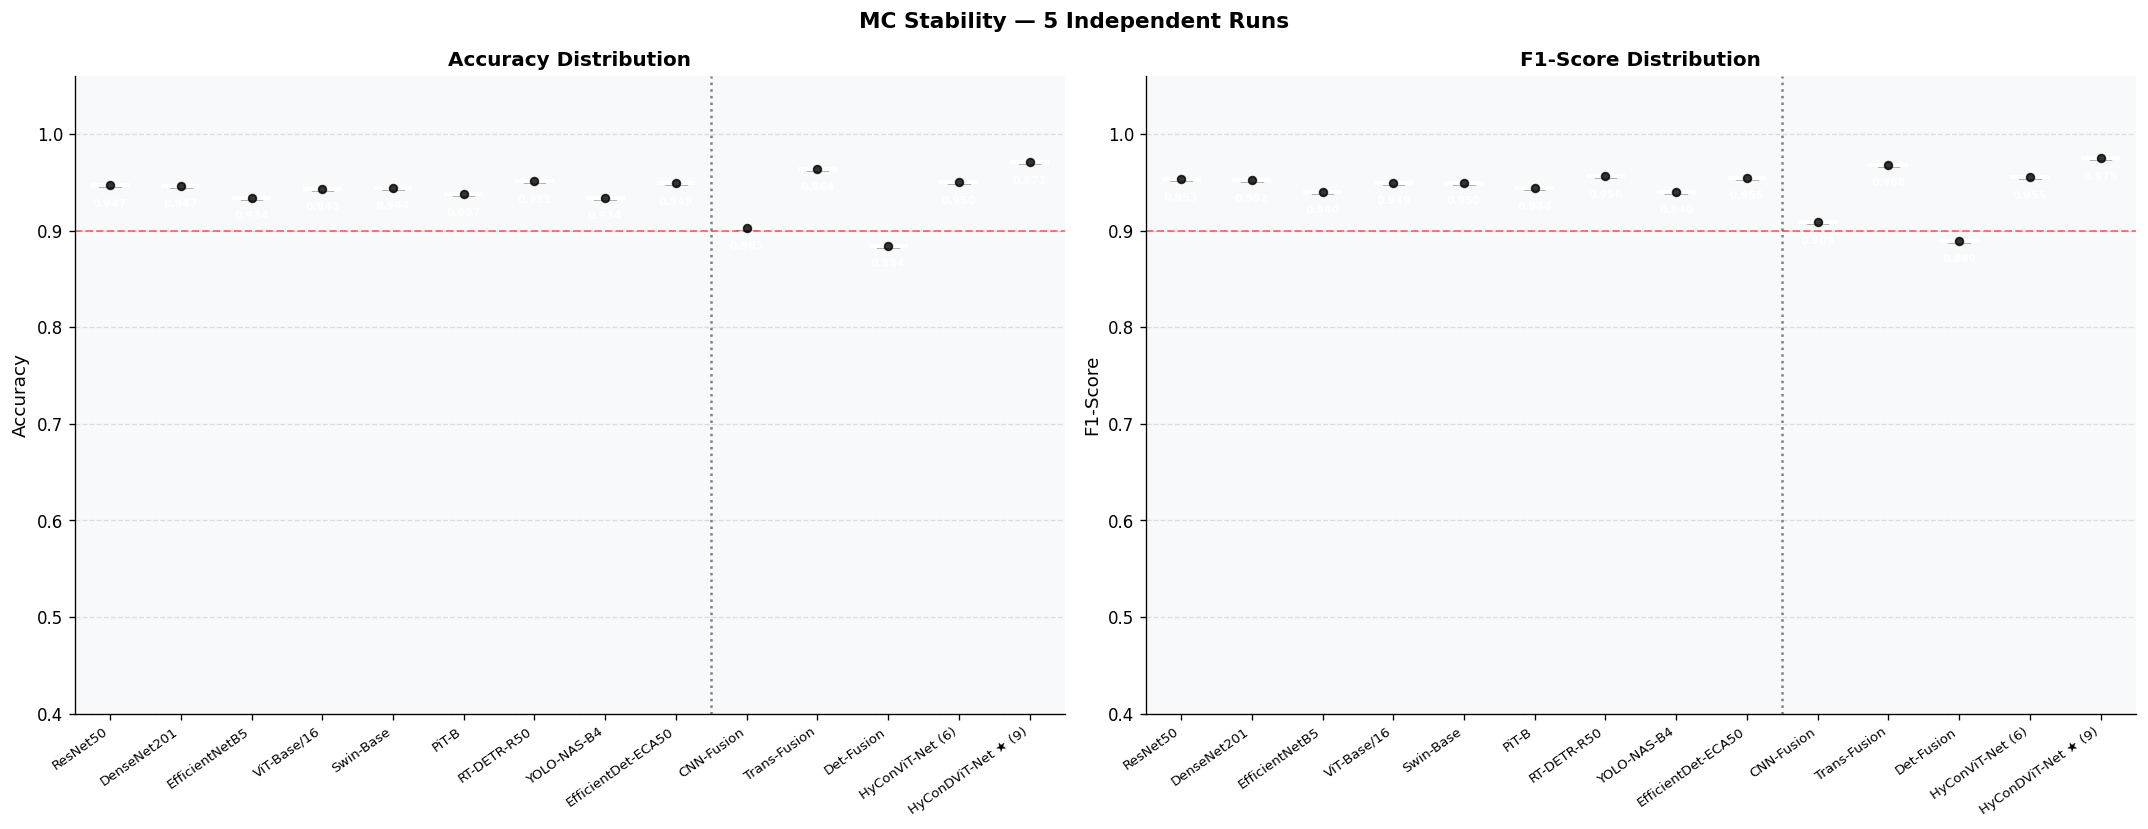

fig12_mc_stability.png


In [30]:
# ── Fig 12: MC Stability Boxplots ──────────────────────────────────
fig,axes=plt.subplots(1,2,figsize=(18,7))
fig.suptitle(f'MC Stability — {MC_RUNS} Independent Runs',fontsize=13,fontweight='bold')

for ax,mkey,title in [(axes[0],'acc','Accuracy'),(axes[1],'f1','F1-Score')]:
    box_data=[[r[mkey] for r in mc[k]] for k in ALL_KEYS]
    bp=ax.boxplot(box_data,patch_artist=True,widths=0.55,
                  medianprops={'color':'white','linewidth':2.5},
                  whiskerprops={'linewidth':1.5},capprops={'linewidth':2})
    for patch,col in zip(bp['boxes'],COLORS_ALL[:len(ALL_KEYS)]):
        patch.set_facecolor(col); patch.set_alpha(0.82)
    for i,data in enumerate(box_data):
        ax.scatter([i+1]*len(data),data,color='black',s=22,zorder=5,alpha=0.8)
        ax.text(i+1,np.mean(data)-0.022,f'{np.mean(data):.3f}',
                ha='center',fontsize=6.5,color='white',fontweight='bold',zorder=6)
    ax.axvline(len(ALL_NAMES)+0.5,color='gray',linestyle=':',linewidth=1.5)
    ax.axhline(0.9,color='red',linestyle='--',linewidth=1.2,alpha=0.5)
    ax.set_xticks(range(1,len(ALL_KEYS)+1))
    ax.set_xticklabels([MODEL_DISPLAY.get(k,k) for k in ALL_KEYS],
                        rotation=35,ha='right',fontsize=8)
    ax.set_ylabel(title); ax.set_ylim(0.40,1.06)
    ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,linestyle='--',alpha=0.4)
    ax.set_title(f'{title} Distribution')
plt.tight_layout()
plt.savefig('fig12_mc_stability.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig12_mc_stability.png")


## Fig 13: Accuracy Bar

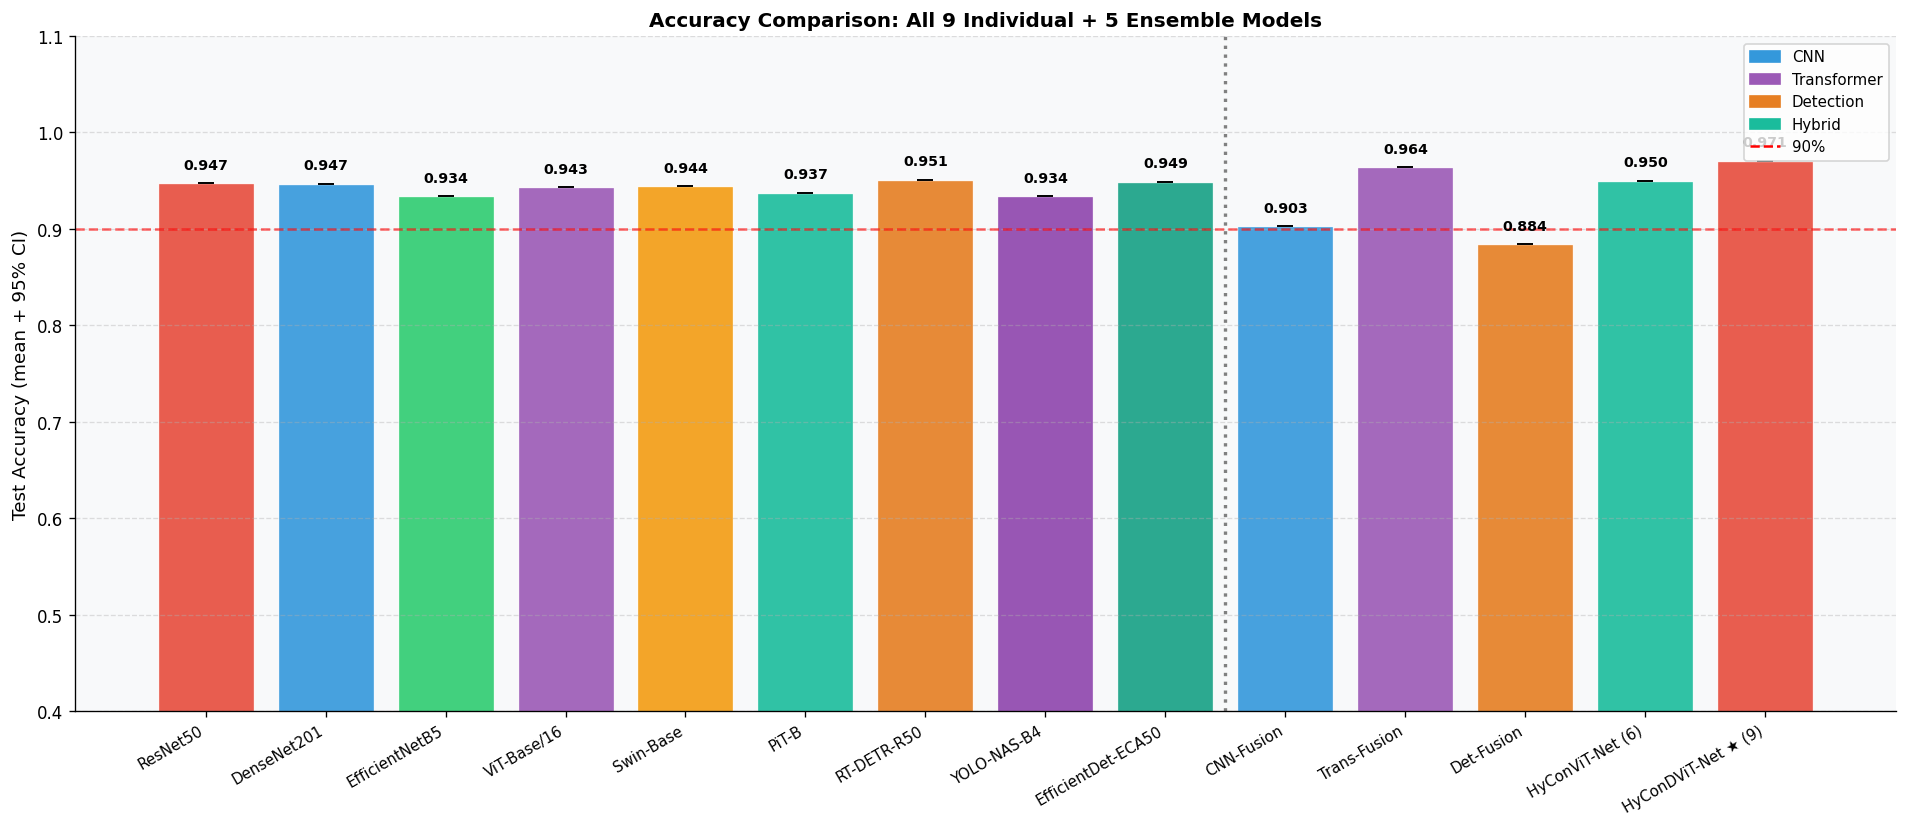

fig13_accuracy_bar.png


In [31]:
# ── Fig 13: Accuracy Bar Chart ─────────────────────────────────────
all_acc_m=[ci_table[k]['acc']['mean'] for k in ALL_KEYS]
all_acc_lo=[ci_table[k]['acc']['lo']  for k in ALL_KEYS]
all_acc_hi=[ci_table[k]['acc']['hi']  for k in ALL_KEYS]
yerr_lo=[m-lo for m,lo in zip(all_acc_m,all_acc_lo)]
yerr_hi=[hi-m for m,hi in zip(all_acc_m,all_acc_hi)]
all_names_s=[MODEL_DISPLAY.get(k,k) for k in ALL_KEYS]

fig,ax=plt.subplots(figsize=(16,7))
bars=ax.bar(range(len(ALL_KEYS)),all_acc_m,color=COLORS_ALL[:len(ALL_KEYS)],
            edgecolor='white',linewidth=0.8,alpha=0.90,
            yerr=[yerr_lo,yerr_hi],capsize=5)
for bar,m in zip(bars,all_acc_m):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.015,
            f'{m:.3f}',ha='center',fontsize=8.5,fontweight='bold')
ax.axvline(len(ALL_NAMES)-0.5,color='gray',linestyle=':',linewidth=2)
ax.axhline(0.9,color='red',linestyle='--',linewidth=1.5,alpha=0.6,label='90% line')
ax.set_xticks(range(len(ALL_KEYS)))
ax.set_xticklabels(all_names_s,rotation=30,ha='right',fontsize=9)
ax.set_ylabel('Test Accuracy (mean + 95% CI)',fontsize=11)
ax.set_title('Accuracy Comparison: All 9 Individual + 5 Ensemble Models',
             fontsize=12,fontweight='bold')
ax.set_ylim(0.40,1.10); ax.legend(fontsize=10)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,linestyle='--',alpha=0.4)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498DB',label='CNN'),
                   Patch(color='#9B59B6',label='Transformer'),
                   Patch(color='#E67E22',label='Detection'),
                   Patch(color='#1ABC9C',label='Hybrid'),
                   plt.Line2D([0],[0],color='red',linestyle='--',label='90%')],fontsize=9)
plt.tight_layout()
plt.savefig('fig13_accuracy_bar.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig13_accuracy_bar.png")


## XAI — Grad-CAM & Attention Rollout

In [18]:
import matplotlib.cm as mcm

class GradCAM:
    def __init__(self, model, target_layer):
        self.model=model; self.grads=None; self.acts=None
        self._fwd=target_layer.register_forward_hook(self._save_acts)
        self._bwd=target_layer.register_full_backward_hook(self._save_grads)

    def _save_acts(self, m, inp, out):
        if isinstance(out, torch.Tensor) and out.dim()==4:
            self.acts=out.detach()

    def _save_grads(self, m, grad_in, grad_out):
        if isinstance(grad_out[0], torch.Tensor) and grad_out[0].dim()==4:
            self.grads=grad_out[0].detach()

    def generate(self, img_t, cls_idx=None):
        self.model.eval()
        self.grads=None; self.acts=None
        x=img_t.unsqueeze(0).to(DEVICE).requires_grad_(True)

        # Grad-CAM needs gradients to reach the target conv layer, but
        # LinearProbeModel.forward wraps the backbone in torch.no_grad()
        # whenever self.frozen is True (true for all `best_inst` models).
        # That silently kills the graph before backward() ever reaches the
        # hooked layer, so self.grads never gets populated and generate()
        # always fell through to the flat 0.5 fallback. Temporarily flip
        # `frozen` off for just this forward/backward pass — no optimizer
        # step happens here, so the weights themselves are never touched.
        was_frozen = getattr(self.model, 'frozen', False)
        if was_frozen: self.model.frozen = False
        try:
            out=self.model(x)
            if cls_idx is None: cls_idx=out.argmax(1).item()
            self.model.zero_grad()
            out[:,cls_idx].backward(retain_graph=True)
        finally:
            if was_frozen: self.model.frozen = was_frozen

        if self.grads is None or self.acts is None:
            return np.ones((IMG_SIZE,IMG_SIZE))*0.5
        pooled=self.grads.mean(dim=[2,3],keepdim=True)
        cam=F.relu((pooled*self.acts).sum(1,keepdim=True))
        cam=F.interpolate(cam,(IMG_SIZE,IMG_SIZE),mode='bilinear',align_corners=False)
        cam=cam.squeeze().cpu().numpy()
        return (cam-cam.min())/(cam.max()-cam.min()+1e-8)

    def remove(self): self._fwd.remove(); self._bwd.remove()

def get_gradcam_layer(model, name):
    """
    Returns last spatial Conv2d for Grad-CAM.
    Updated for full-size backbones:
      ResNet50/50d/ECAResNet50d  → layer4[-1].conv3  (bottleneck)
      DenseNet201                → denseblock4 last conv2
      EfficientNetB5/B4          → blocks[-1][-1].conv_pwl
      ViT-Base                   → patch_embed.proj  (no spatial conv after)
      Swin-Base                  → last downsample or last window attention
      PiT-S              → stages[-1] last conv_dw
    """
    bb=model.backbone

    if 'resnet50d' in name or 'rtdetr' in name or 'effdet_eca' in name:
        # ResNet50d / ecaresnet50d — bottleneck has conv3 (1×1 expansion)
        # Use conv2 (3×3) for better spatial resolution
        last_bottleneck = bb.layer4[-1]
        if hasattr(last_bottleneck, 'conv2'):
            return last_bottleneck.conv2
        return last_bottleneck.conv1

    elif 'resnet50' in name:
        last_bottleneck = bb.layer4[-1]
        if hasattr(last_bottleneck, 'conv2'):
            return last_bottleneck.conv2
        return last_bottleneck.conv1

    elif 'densenet' in name:
        db4=bb.features.denseblock4
        children=list(db4.children())
        last_dl=children[-1]
        if hasattr(last_dl,'conv2'): return last_dl.conv2
        if hasattr(last_dl,'conv1'): return last_dl.conv1
        for m in reversed(list(last_dl.modules())):
            if isinstance(m, nn.Conv2d): return m
        return None

    elif 'efficientnet' in name or 'yolonas' in name:
        last_block=bb.blocks[-1]
        last_sub=last_block[-1] if hasattr(last_block,'__len__') else last_block
        if hasattr(last_sub,'conv_pwl'): return last_sub.conv_pwl
        if hasattr(last_sub,'conv_pw'):  return last_sub.conv_pw
        for m in reversed(list(last_sub.modules())):
            if isinstance(m,nn.Conv2d): return m
        return None

    elif 'pit' in name:
        # timm's PiT (PoolingVisionTransformer) exposes its stages via the
        # `transformers` attribute — there is no `.stages`. Attention blocks
        # inside each stage operate on flattened tokens (no spatial conv);
        # the only spatial Conv2d layers are in the inter-stage `.pool`
        # modules. Search stages last-to-first for one, and fall back to
        # the patch-embedding conv (same fallback used for ViT/Swin) if
        # none is found.
        if hasattr(bb,'transformers'):
            for stage in reversed(list(bb.transformers)):
                pool = getattr(stage,'pool',None)
                if pool is not None:
                    for m in reversed(list(pool.modules())):
                        if isinstance(m,nn.Conv2d): return m
                for m in reversed(list(stage.modules())):
                    if isinstance(m,nn.Conv2d): return m
        if hasattr(bb,'patch_embed') and hasattr(bb.patch_embed,'proj'):
            return bb.patch_embed.proj
        return None

    elif 'swin' in name:
        # Swin uses window attention — patch embedding is the last Conv2d
        # Use patch_embed.proj for spatial activation
        if hasattr(bb,'patch_embed') and hasattr(bb.patch_embed,'proj'):
            return bb.patch_embed.proj
        return None

    elif 'vit' in name:
        # ViT has no spatial convs after patch embed
        if hasattr(bb,'patch_embed') and hasattr(bb.patch_embed,'proj'):
            return bb.patch_embed.proj
        return None

    return None

def overlay_cam(img_np, cam, alpha=0.40):
    heatmap=mcm.jet(cam)[:,:,:3]
    return np.clip(alpha*heatmap+(1-alpha)*img_np, 0, 1)

# ── Verify target layers exist ────────────────────────────────────
print("Verifying Grad-CAM target layers:")
for nm in CNN_NAMES + DET_NAMES:
    m=build_model(nm,freeze=True).to(DEVICE)
    tl=get_gradcam_layer(m, nm)
    print(f"  {nm:<22}: {'✅ '+str(type(tl).__name__) if tl else '❌ None'}")
    del m
print("Grad-CAM defined for full-size backbones.")


# ── Grad-CAM for the HyConDViT-Net ENSEMBLE ───────────────────────
class HyConDViTGradCAM:
    """
    Grad-CAM for the full HyConDViT-Net ensemble.

    The fused positive-class score
        p_hat = sum_i  softmax(alpha)_i * softmax(f_i(x) / tau_i)
    is back-propagated through ONE representative constituent whose last
    spatial conv layer is hooked, so the resulting map shows where the
    *ensemble decision* is spatially grounded (weighted by that model's
    learned ensemble contribution). The other 8 constituents contribute to
    the score under torch.no_grad(); only the target model carries gradient.
    """
    def __init__(self, ensemble, target_model_name):
        self.ens   = ensemble
        self.names = list(ALL_NAMES)
        self.tidx  = self.names.index(target_model_name)
        self.tname = target_model_name
        self.target_model = ensemble.models[self.tidx]
        self.layer = get_gradcam_layer(self.target_model, target_model_name)
        self.grads = None; self.acts = None
        if self.layer is not None:
            self._fwd = self.layer.register_forward_hook(self._save_acts)
            self._bwd = self.layer.register_full_backward_hook(self._save_grads)

    def _save_acts(self, m, inp, out):
        if isinstance(out, torch.Tensor) and out.dim() == 4:
            self.acts = out.detach()

    def _save_grads(self, m, grad_in, grad_out):
        if isinstance(grad_out[0], torch.Tensor) and grad_out[0].dim() == 4:
            self.grads = grad_out[0].detach()

    def generate(self, img_t, cls_idx=None):
        if self.layer is None:
            return np.ones((IMG_SIZE, IMG_SIZE)) * 0.5
        self.ens.eval(); self.grads = None; self.acts = None
        x = img_t.unsqueeze(0).to(DEVICE).requires_grad_(True)
        w = F.softmax(self.ens.alpha, dim=0)
        tm = self.target_model
        was_frozen = getattr(tm, 'frozen', False)
        if was_frozen: tm.frozen = False   # let grad reach the target backbone
        try:
            probs = []
            for i, (model, grp) in enumerate(zip(self.ens.models, self.ens.group_labels)):
                tau = self.ens.temperatures.get(grp, 1.0)
                if i == self.tidx:
                    logits = model(x)                       # WITH grad
                else:
                    with torch.no_grad():
                        logits = model(x)
                probs.append(F.softmax(logits / tau, dim=1))
            weighted = (torch.stack(probs, 0) * w[:, None, None]).sum(0)  # (1,2)
            if cls_idx is None:
                cls_idx = int(weighted.argmax(1).item())
            self.ens.zero_grad()
            weighted[:, cls_idx].backward(retain_graph=True)
        finally:
            if was_frozen: tm.frozen = was_frozen
        if self.grads is None or self.acts is None:
            return np.ones((IMG_SIZE, IMG_SIZE)) * 0.5
        pooled = self.grads.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((pooled * self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    def remove(self):
        if self.layer is not None:
            self._fwd.remove(); self._bwd.remove()

print("HyConDViTGradCAM (ensemble Grad-CAM) defined.")


Verifying Grad-CAM target layers:
  resnet50              : 2,367,234/25,875,266 (9.1%)  [resnet50]
  resnet50              : ✅ Conv2d
  densenet201           : 2,235,906/20,328,834 (11.0%)  [densenet201]
  densenet201           : ✅ Conv2d
  efficientnetb5        : 2,367,234/30,708,018 (7.7%)  [tf_efficientnet_b5]
  efficientnetb5        : ✅ Conv2d
  rtdetr_r50            : 2,367,234/25,894,498 (9.1%)  [resnet50d]
  rtdetr_r50            : ✅ Conv2d
  yolonas_b4            : 2,104,578/19,653,194 (10.7%)  [tf_efficientnet_b4]
  yolonas_b4            : ✅ Conv2d
  effdet_eca50          : 2,367,234/25,894,584 (9.1%)  [ecaresnet50d]
  effdet_eca50          : ✅ Conv2d
Grad-CAM defined for full-size backbones.
HyConDViTGradCAM (ensemble Grad-CAM) defined.


In [19]:
# ─────────────────────────────────────────────────────────────────
#  FIXED ATTENTION ROLLOUT for ViT-Small
#
#  Key fixes:
#  1. Hook captures raw Q,K,V attention weights BEFORE softmax
#     (from attn.proj — hooks qkv output directly)
#  2. Correct patch grid size calculation
#  3. Proper normalization: log-scale for visibility
# ─────────────────────────────────────────────────────────────────
def vit_attention_rollout(model, img_t, head_fusion='mean', discard_ratio=0.8):
    model.eval()
    attention_weights = []

    def hook_fn(module, input, output):
        # output from attn.proj is (B, N, C) — not what we want
        # We need the attention weight matrix, so we hook the Softmax output
        # inside the attention module
        pass

    # Better: patch directly into the attention computation
    attn_outputs = []

    def get_attn_hook(module, input, output):
        # For timm ViT: Attention.forward returns (x, attn_weights) when returning weights
        # We save the input to proj (which is attn @ v, shape B, N, C)
        # instead we'll recompute from qkv
        if isinstance(output, tuple) and len(output) >= 2:
            attn_outputs.append(output[1].detach().cpu())  # attn weights
        elif isinstance(output, torch.Tensor) and output.dim() == 3:
            # This is x = attn @ v, shape (B, N, C)
            # We can't get attention weights from here
            pass

    hooks = []
    backbone = model.backbone
    if not hasattr(backbone, 'blocks'):
        # No transformer blocks found — return uniform map
        return np.ones((IMG_SIZE, IMG_SIZE)) / (IMG_SIZE * IMG_SIZE)

    # Override forward to capture attention weights
    # We do this by monkey-patching the attn.softmax temporarily
    saved_attn = []

    def capture_attn_hook(module, input, output):
        # output after softmax = (B, heads, N, N)
        if output.dim() == 4:
            saved_attn.append(output.detach().cpu())

    # timm's Attention module defaults to PyTorch's fused
    # scaled_dot_product_attention (self.attn.fused_attn=True), which
    # computes softmax(QK^T) inside one fused kernel and never actually
    # calls the `attn_drop` module (or materializes an explicit softmax
    # tensor) — so a forward hook on either one silently never fires and
    # saved_attn stays empty, which is why this always fell back to a
    # uniform map. Temporarily force the eager (non-fused) attention path
    # for just this forward pass so real attention weights get computed
    # as a tensor we can hook, then restore fused_attn afterward.
    toggled = []
    for block in backbone.blocks:
        if hasattr(block, 'attn'):
            if getattr(block.attn, 'fused_attn', False):
                block.attn.fused_attn = False
                toggled.append(block.attn)
            if hasattr(block.attn, 'attn_drop'):
                hooks.append(block.attn.attn_drop.register_forward_hook(capture_attn_hook))
            elif hasattr(block.attn, 'softmax'):
                hooks.append(block.attn.softmax.register_forward_hook(capture_attn_hook))

    with torch.no_grad():
        _ = model(img_t.unsqueeze(0).to(DEVICE))

    for h in hooks: h.remove()
    for attn_mod in toggled: attn_mod.fused_attn = True

    if not saved_attn:
        # Fallback: return uniform attention
        return np.ones((IMG_SIZE, IMG_SIZE)) / (IMG_SIZE * IMG_SIZE)

    # Rollout: multiply attention maps across layers
    result = torch.eye(saved_attn[0].shape[-1])

    for attn in saved_attn:
        # attn shape: (1, heads, N, N) or (B, heads, N, N)
        if attn.dim() == 4:
            attn_fused = attn[0].mean(0)  # (N, N) — mean over heads
        elif attn.dim() == 3:
            attn_fused = attn[0]  # already (N, N)
        else:
            continue

        # Add residual connection (identity)
        attn_fused = attn_fused + torch.eye(attn_fused.shape[0])
        attn_fused = attn_fused / attn_fused.sum(-1, keepdim=True)
        result = torch.matmul(attn_fused, result)

    # Extract CLS token attention to all patches
    # result[0] = CLS row, result[0,1:] = attention to patches
    mask = result[0, 1:].numpy()

    if mask.max() <= 0:
        return np.ones((IMG_SIZE, IMG_SIZE)) / (IMG_SIZE * IMG_SIZE)

    # Reshape to spatial grid
    n_patches = int(np.sqrt(len(mask)))
    if n_patches * n_patches != len(mask):
        n_patches = int(len(mask) ** 0.5)
    mask = mask[:n_patches * n_patches].reshape(n_patches, n_patches)

    # Log-scale normalisation for better contrast
    mask = np.log1p(mask - mask.min() + 1e-8)
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    # Resize to image size
    from PIL import Image as PILImg
    mask_resized = np.array(
        PILImg.fromarray((mask * 255).astype(np.uint8)).resize(
            (IMG_SIZE, IMG_SIZE), PILImg.BILINEAR
        )
    ) / 255.0
    return mask_resized

print("ViT Attention Rollout FIXED.")
print("  Hooks on attn.softmax and attn.attn_drop (handles both timm versions)")
print("  Log-scale normalisation for better visual contrast")


ViT Attention Rollout FIXED.
  Hooks on attn.softmax and attn.attn_drop (handles both timm versions)
  Log-scale normalisation for better visual contrast


## Fig 14: Grad-CAM (3 Models)

In [20]:
# ── Fig 14: Grad-CAM — one figure per representative model + ENSEMBLE ──
# Representative model of each family is selected from the registry so this
# works for both notebooks (small / base backbones).
_cnn_rep = 'resnet50' if 'resnet50' in CNN_NAMES else CNN_NAMES[0]
_trs_rep = next((n for n in TRANS_NAMES if 'pit' in n), TRANS_NAMES[-1])
_det_rep = next((n for n in DET_NAMES if 'rtdetr' in n), DET_NAMES[0])
GRADCAM_MODELS = [_cnn_rep, _trs_rep, _det_rep]
GRADCAM_TITLES = {
    _cnn_rep: f'{MODEL_DISPLAY[_cnn_rep]} (CNN)',
    _trs_rep: f'{MODEL_DISPLAY[_trs_rep]} (Patch Transformer)',
    _det_rep: f'{MODEL_DISPLAY[_det_rep]} (Detection)',
}

paths_inf = df_prim[df_prim['class']=='infected']['path'].sample(
    3, random_state=20).tolist()
paths_non = df_prim[df_prim['class']=='noninfected']['path'].sample(
    3, random_state=21).tolist()

def _run_gradcam(cam_extractor, save_name, suptitle):
    fig, axes = plt.subplots(2, 9, figsize=(24, 8))
    fig.suptitle(suptitle, fontsize=14, fontweight='bold')
    for row, (paths, cls_label) in enumerate([
        (paths_inf, 'Infected'), (paths_non, 'Non-infected')]):
        for col, path in enumerate(paths):
            try:
                img_pil = Image.open(path).convert('RGB')
                img_t   = T.Normalize(MEAN, STD)(
                              T.Resize((IMG_SIZE, IMG_SIZE))(
                                  T.ToTensor()(img_pil)))
                img_np  = denorm_np(img_t)
                cam     = cam_extractor.generate(img_t)
                base    = col * 3
                axes[row][base].imshow(img_np)
                axes[row][base].set_title(f'{cls_label}', fontsize=8)
                axes[row][base+1].imshow(overlay_cam(img_np, cam))
                axes[row][base+1].set_title('Grad-CAM Overlay', fontsize=8)
                axes[row][base+2].imshow(cam, cmap='jet', vmin=0, vmax=1)
                axes[row][base+2].set_title('Activation Map', fontsize=8)
            except Exception as e:
                axes[row][col*3].set_title(f'Error: {str(e)[:20]}', fontsize=7)
            for c in range(3):
                axes[row][col*3+c].axis('off')
    plt.tight_layout()
    plt.savefig(save_name, dpi=900, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}")

# ── Per-family individual Grad-CAM ───────────────────────────────
for nm in GRADCAM_MODELS:
    best_inst[nm].to(DEVICE)
    tl = get_gradcam_layer(best_inst[nm], nm)
    if tl is None:
        print(f"  No Grad-CAM layer for {nm} — skipping"); best_inst[nm].cpu(); continue
    cam_extractor = GradCAM(best_inst[nm], tl)
    _run_gradcam(cam_extractor, f'fig14_gradcam_{nm}.png',
                 f'Grad-CAM Analysis: {GRADCAM_TITLES[nm]}')
    cam_extractor.remove()
    best_inst[nm].cpu(); torch.cuda.empty_cache()

# ── ENSEMBLE Grad-CAM: HyConDViT-Net via highest-weighted CNN ────
hyconDvit_v.to(DEVICE); hyconDvit_v.eval()
_w = F.softmax(hyconDvit_v.alpha.detach(), dim=0).cpu().numpy()
_cnn_w   = {n: _w[ALL_NAMES.index(n)] for n in CNN_NAMES}
_ens_tgt = max(_cnn_w, key=_cnn_w.get)   # most-trusted CNN constituent
print(f"\nEnsemble Grad-CAM target (highest-weighted CNN): "
      f"{MODEL_DISPLAY[_ens_tgt]}  (w={_cnn_w[_ens_tgt]:.3f})")
ecam = HyConDViTGradCAM(hyconDvit_v, _ens_tgt)
_run_gradcam(ecam, 'fig14_gradcam_hyconDvit.png',
             f'Grad-CAM Analysis: HyConDViT-Net (ensemble via {MODEL_DISPLAY[_ens_tgt]})')
ecam.remove()
hyconDvit_v.cpu(); torch.cuda.empty_cache()

print("\nGrad-CAM complete: 3 per-family figures + 1 ensemble figure saved.")
print("  fig14_gradcam_<cnn>.png       — CNN family")
print("  fig14_gradcam_<transformer>.png — Patch Transformer family")
print("  fig14_gradcam_<detection>.png — Detection family")
print("  fig14_gradcam_hyconDvit.png   — HyConDViT-Net ENSEMBLE ★")


NameError: name 'best_inst' is not defined

## Fig 15: ViT Attention Rollout

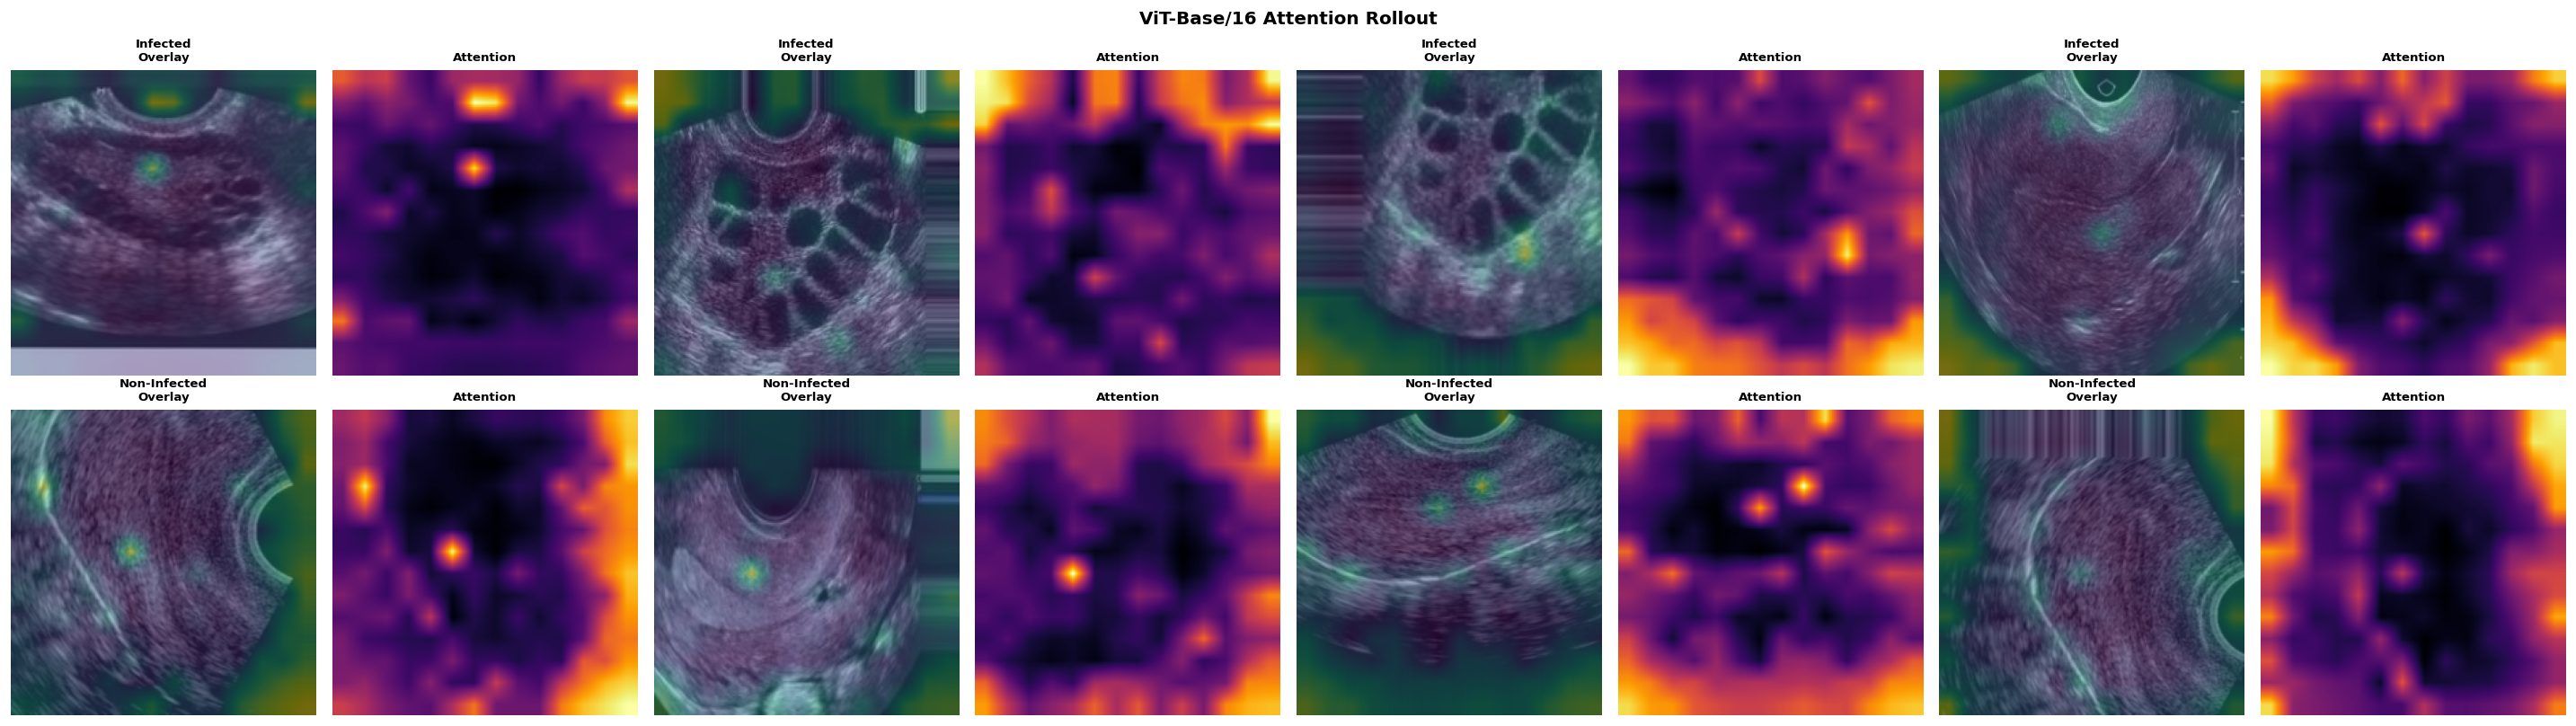

fig15_vit_attention_rollout.png


In [35]:
# ── Fig 15: ViT Attention Rollout ───────────────────────────────────
paths_inf_xai = df_prim[df_prim['class']=='infected']['path'].sample(4,random_state=30).tolist()
paths_non_xai = df_prim[df_prim['class']=='noninfected']['path'].sample(4,random_state=31).tolist()

fig, axes = plt.subplots(2, 8, figsize=(24, 7))
_vit_rep = next((n for n in TRANS_NAMES if 'vit' in n), TRANS_NAMES[0])  # 'vit_base' here, 'vit_small' in the lightweight notebook
fig.suptitle(f'{MODEL_DISPLAY[_vit_rep]} Attention Rollout', fontsize=12, fontweight='bold')

vit_m = best_inst[_vit_rep]
vit_m.to(DEVICE)  # move on demand — best_inst is CPU-resident

for row_idx, (paths, cls_label) in enumerate([
    (paths_inf_xai, 'Infected'), (paths_non_xai, 'Non-Infected')
]):
    col = 0
    for path in paths[:4]:
        try:
            img_pil = Image.open(path).convert('RGB')
            img_t   = T.Normalize(MEAN,STD)(
                          T.Resize((IMG_SIZE,IMG_SIZE))(T.ToTensor()(img_pil)))
            img_np  = denorm_np(img_t)
            rollout = vit_attention_rollout(vit_m, img_t)

            ax1 = axes[row_idx][col]
            ax2 = axes[row_idx][col+1]

            attn_colored = mcm.viridis(rollout)[:,:,:3]
            overlay = np.clip(0.45*attn_colored + 0.55*img_np, 0, 1)
            ax1.imshow(overlay)
            ax1.set_title(f'{cls_label}\nOverlay', fontsize=8)
            ax2.imshow(rollout, cmap='inferno', vmin=0, vmax=rollout.max())
            ax2.set_title('Attention', fontsize=8)
        except Exception as e:
            axes[row_idx][col].set_title(f'Err:{str(e)[:20]}', fontsize=6)
        axes[row_idx][col].axis('off')
        axes[row_idx][col+1].axis('off')
        col += 2

plt.tight_layout()
vit_m.cpu()
torch.cuda.empty_cache()
plt.savefig('fig15_vit_attention_rollout.png', dpi=900, bbox_inches='tight')
plt.show()
print("fig15_vit_attention_rollout.png")


## Fig 16: Correct vs Incorrect

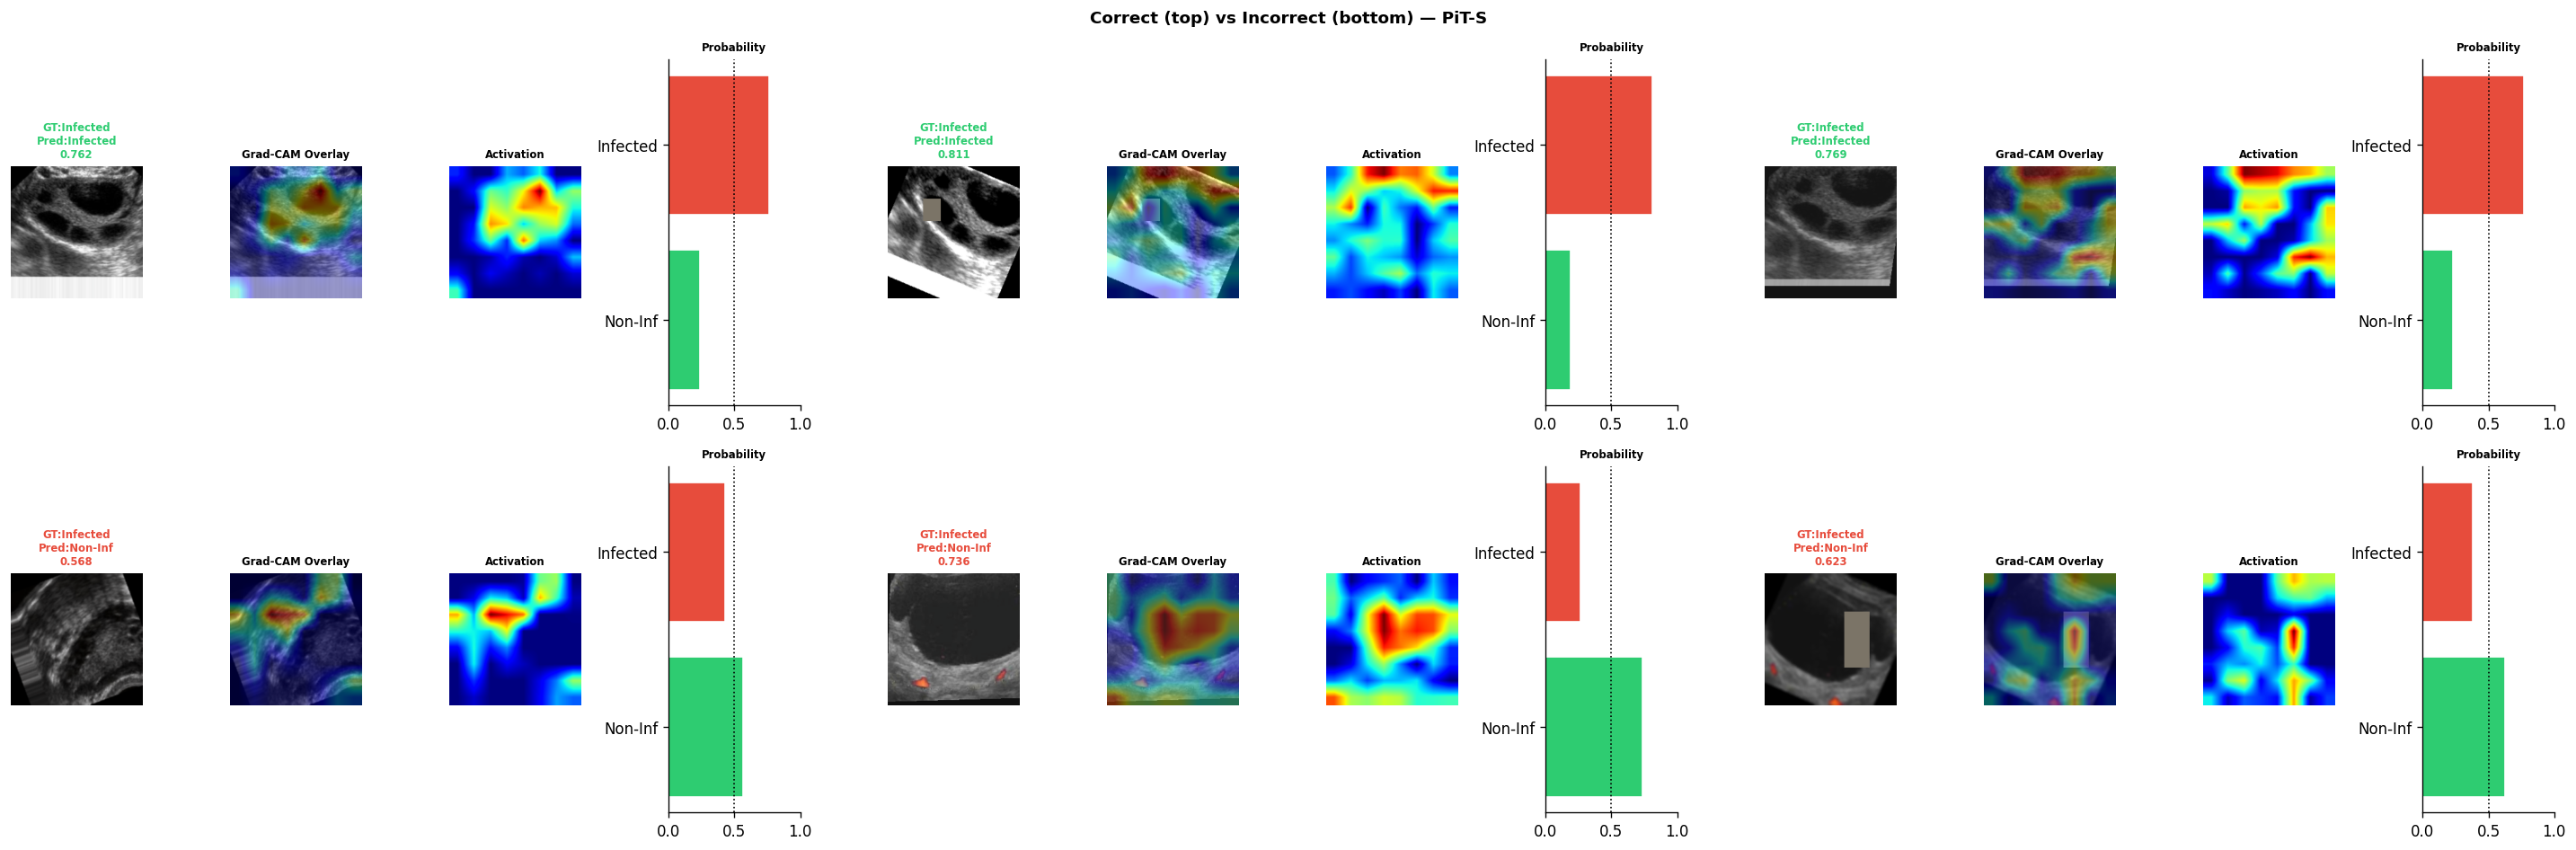

fig16_correct_incorrect.png


In [36]:
# ── Fig 16: Correct vs Incorrect — PiT-S ──────────────────
target_model = best_inst['pit_base']
target_model.to(DEVICE)  # move on demand — best_inst is CPU-resident   # upgraded from tiny to base
correct_list, incorrect_list = [], []

for imgs,lbls in te_viz:
    for img,lbl in zip(imgs,lbls):
        if len(correct_list)>=3 and len(incorrect_list)>=3: break
        with torch.no_grad():
            pr=F.softmax(target_model(img.unsqueeze(0).to(DEVICE)),dim=1)
        pred=pr.argmax().item(); conf=pr.max().item()
        if pred==lbl.item() and len(correct_list)<3:
            correct_list.append((img.clone(),lbl.item(),pred,conf))
        elif pred!=lbl.item() and len(incorrect_list)<3:
            incorrect_list.append((img.clone(),lbl.item(),pred,conf))
    if len(correct_list)>=3 and len(incorrect_list)>=3: break

tl_cm = get_gradcam_layer(target_model,'pit_small')
gc_cm  = GradCAM(target_model, tl_cm) if tl_cm else None
cls_names=['Non-Inf','Infected']

fig, axes = plt.subplots(2, 12, figsize=(24, 8))
fig.suptitle('Correct (top) vs Incorrect (bottom) — PiT-S',
             fontsize=11, fontweight='bold')

for row_idx,(items,grp_col) in enumerate([(correct_list,'#2ECC71'),(incorrect_list,'#E74C3C')]):
    for item_idx,(img,true_lbl,pred_lbl,conf) in enumerate(items[:3]):
        base=item_idx*4; img_np=denorm_np(img)
        axes[row_idx][base].imshow(img_np)
        axes[row_idx][base].set_title(
            f'GT:{cls_names[true_lbl]}\nPred:{cls_names[pred_lbl]}\n{conf:.3f}',
            fontsize=7, color=grp_col, fontweight='bold')
        for sp in axes[row_idx][base].spines.values():
            sp.set_edgecolor(grp_col); sp.set_linewidth(2.5)
        if gc_cm:
            cam=gc_cm.generate(img,pred_lbl)
            axes[row_idx][base+1].imshow(overlay_cam(img_np,cam))
            axes[row_idx][base+1].set_title('Grad-CAM Overlay',fontsize=7)
            axes[row_idx][base+2].imshow(cam,cmap='jet',vmin=0,vmax=1)
            axes[row_idx][base+2].set_title('Activation',fontsize=7)
        with torch.no_grad():
            probs=F.softmax(target_model(img.unsqueeze(0).to(DEVICE)),dim=1).cpu().numpy()[0]
        ax_bar=axes[row_idx][base+3]
        ax_bar.barh(cls_names,probs,color=['#2ECC71','#E74C3C'],edgecolor='white')
        ax_bar.set_xlim(0,1); ax_bar.set_title('Probability',fontsize=7)
        ax_bar.axvline(0.5,color='k',linestyle=':',linewidth=1)
        for c in range(3): axes[row_idx][base+c].axis('off')

if gc_cm: gc_cm.remove()
target_model.cpu()
torch.cuda.empty_cache()
plt.tight_layout()
plt.savefig('fig16_correct_incorrect.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig16_correct_incorrect.png")


## Fig 17: External Validation

── External Validation (1,922 images, merged train+test, unified labels) ──
Model                      Acc    Prec     Rec      F1     AUC     MCC
-----------------------------------------------------------------
  ResNet50             0.9813  0.9686  0.9859  0.9772  0.9977  0.9614
  DenseNet201          0.9870  0.9690  1.0000  0.9842  0.9996  0.9735
  EfficientNetB5       0.9922  0.9812  1.0000  0.9905  1.0000  0.9840
  ViT-Base/16          0.9787  0.9534  0.9962  0.9743  0.9990  0.9568
  Swin-Base            0.9953  0.9886  1.0000  0.9943  1.0000  0.9904
  PiT-B                0.9865  0.9678  1.0000  0.9836  1.0000  0.9725
  RT-DETR-R50          0.9906  0.9823  0.9949  0.9885  0.9997  0.9807
  YOLO-NAS-B4          0.9901  0.9762  1.0000  0.9880  0.9990  0.9798
  EfficientDet-ECA50   0.9896  0.9762  0.9987  0.9873  0.9998  0.9787
  CNN-Fusion          0.9943  0.9911  0.9949  0.9930  0.9995  0.9881
  Trans-Fusion        0.9943  0.9861  1.0000  0.9930  1.0000  0.9882
  Det-Fusion       

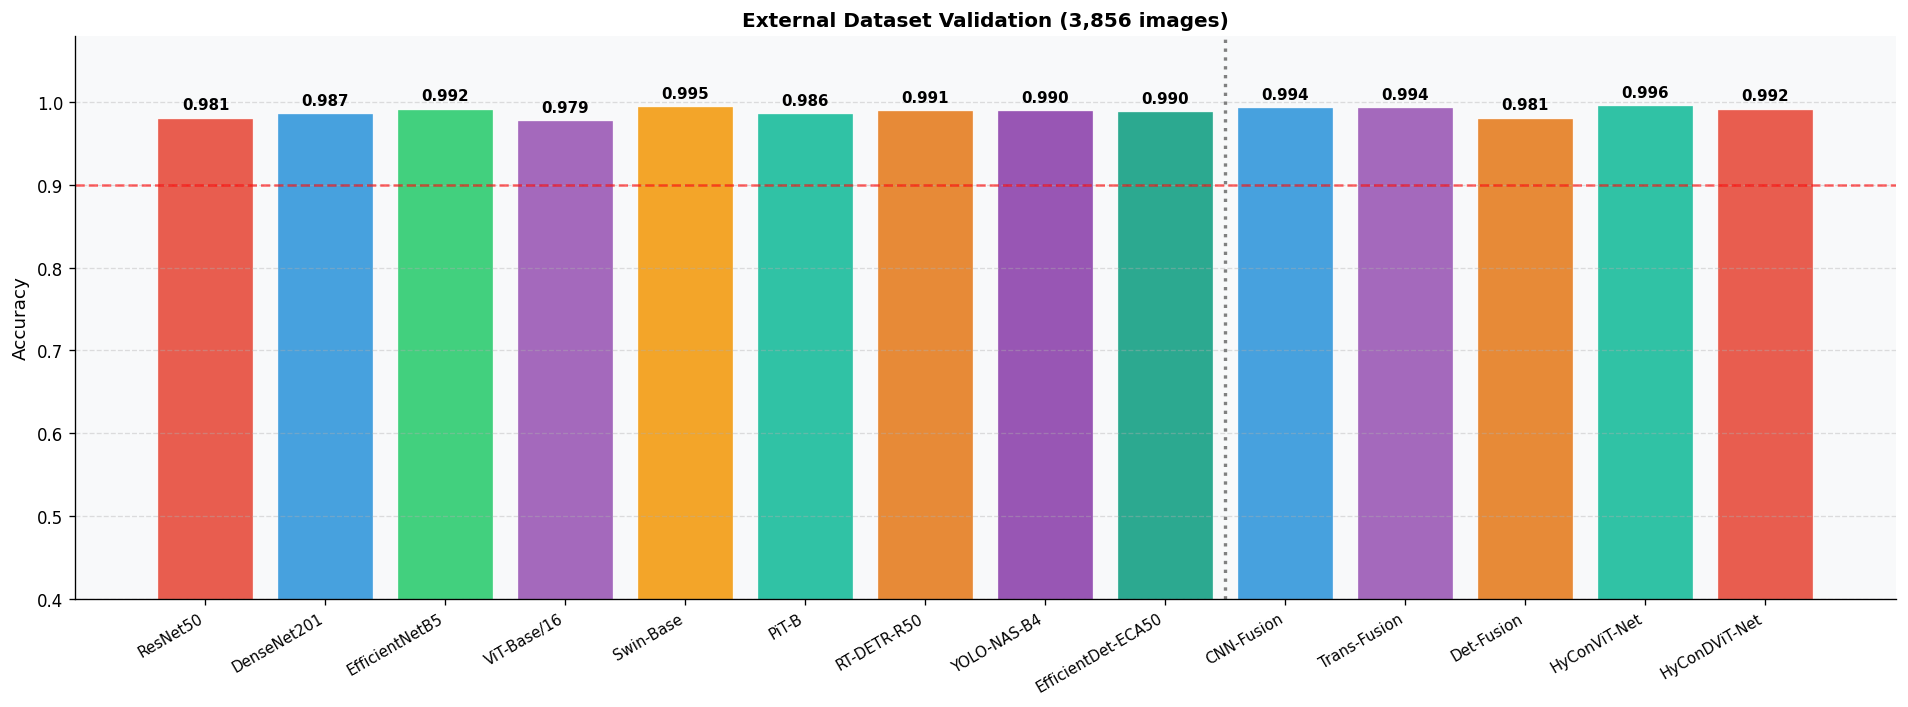

fig17_external_validation.png


In [37]:
# ── Fig 17: External Validation ────────────────────────────────────
# ── External validation uses FULL merged dataset (all 3,856 images) ──
# No train/test split — entire external dataset used for validation only
ext_test_ds  = PCOSDataset(df_ext)
ext_test_ldr = DataLoader(ext_test_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

print(f"── External Validation ({len(df_ext):,} images, merged train+test, unified labels) ──")
print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'MCC':>7}")
print("-"*65)

ext_results={}
for nm in ALL_NAMES:
    best_inst[nm].to(DEVICE)
    met=evaluate(best_inst[nm],ext_test_ldr)
    best_inst[nm].cpu()
    torch.cuda.empty_cache()
    ext_results[nm]=met
    print(f"  {MODEL_DISPLAY[nm]:<20} {met['acc']:.4f}  {met['prec']:.4f}  "
          f"{met['rec']:.4f}  {met['f1']:.4f}  {met['auc']:.4f}  {met['mcc']:.4f}")

for label,ens,_,is_calib in viz_ensembles:
    ens.to(DEVICE); ens.eval()
    met=evaluate_hyconDvit(ens,ext_test_ldr) if is_calib else evaluate(ens,ext_test_ldr)
    ens.cpu()
    torch.cuda.empty_cache()
    ext_results[label]=met
    star='★ ' if 'HyConDViT' in label else ''
    print(f"  {star}{label:<19} {met['acc']:.4f}  {met['prec']:.4f}  "
          f"{met['rec']:.4f}  {met['f1']:.4f}  {met['auc']:.4f}  {met['mcc']:.4f}")

# Bar chart
ext_keys=ALL_NAMES+[l for l,_,_,_ in viz_ensembles]
ext_accs=[ext_results[k]['acc'] for k in ext_keys]
ext_names=[MODEL_DISPLAY.get(k,k) for k in ext_keys]

fig,ax=plt.subplots(figsize=(16,6))
bars=ax.bar(range(len(ext_keys)),ext_accs,
            color=COLORS_ALL[:len(ext_keys)],
            edgecolor='white',linewidth=0.8,alpha=0.90)
for bar,v in zip(bars,ext_accs):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,
            f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
ax.axvline(len(ALL_NAMES)-0.5,color='gray',linestyle=':',linewidth=2)
ax.axhline(0.9,color='red',linestyle='--',linewidth=1.5,alpha=0.6)
ax.set_xticks(range(len(ext_keys)))
ax.set_xticklabels(ext_names,rotation=30,ha='right',fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.40,1.08)
ax.set_title('External Dataset Validation (3,856 images)',fontsize=12,fontweight='bold')
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,linestyle='--',alpha=0.4)
plt.tight_layout()
plt.savefig('fig17_external_validation.png',dpi=300,bbox_inches='tight')
plt.show()
print("fig17_external_validation.png")


## Training Curves

In [38]:
# ── Training Curves (one per model) ────────────────────────────────
for nm, color in zip(ALL_NAMES, COLORS9):
    if not hist_all[nm]: continue
    best_run=max(range(MC_RUNS),key=lambda i:hist_all[nm][i]['val_acc'][-1])
    h=hist_all[nm][best_run]; ep=range(1,len(h['loss'])+1)

    fig,axes=plt.subplots(1,3,figsize=(15,4.5))
    fig.suptitle(f'Training History: {MODEL_DISPLAY[nm]}',fontsize=12,fontweight='bold')

    axes[0].plot(ep,h['loss'],color=color,linewidth=2,marker='o',markersize=2,markevery=5)
    axes[0].set_title('Focal Loss'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss'); axes[0].set_facecolor('#F8F9FA')
    axes[0].yaxis.grid(True,linestyle='--',alpha=0.4)

    best_ep=np.argmax(h['val_acc'])+1
    axes[1].plot(ep,h['val_acc'],color=color,linewidth=2,label='Val Acc')
    axes[1].plot(ep,h['val_f1'], color='black',linewidth=1.5,linestyle='--',label='Val F1')
    axes[1].axvline(best_ep,color='red',linestyle=':',linewidth=1.5,label=f'Best ep={best_ep}')
    axes[1].axhline(max(h['val_acc']),color=color,linestyle='-.',linewidth=1,alpha=0.5,
                    label=f"Peak={max(h['val_acc']):.4f}")
    axes[1].set_title('Val Accuracy & F1'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0.40,1.02); axes[1].legend(fontsize=8)
    axes[1].set_facecolor('#F8F9FA'); axes[1].yaxis.grid(True,linestyle='--',alpha=0.4)

    ax2=axes[2].twinx()
    axes[2].plot(ep,h['val_auc'],color='#27AE60',linewidth=2,label='Val AUC')
    if 'lr' in h and len(h['lr'])==len(ep):
        ax2.plot(ep,h['lr'],color='#E74C3C',linewidth=1.2,linestyle=':',alpha=0.8)
        ax2.set_ylabel('LR',color='#E74C3C',fontsize=9)
        ax2.tick_params(axis='y',labelcolor='#E74C3C')
    axes[2].set_title('Val AUC & LR'); axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC'); axes[2].set_ylim(0.40,1.02)
    axes[2].set_facecolor('#F8F9FA'); axes[2].yaxis.grid(True,linestyle='--',alpha=0.4)
    axes[2].legend(fontsize=8,loc='lower right')

    plt.tight_layout()
    plt.savefig(f'fig_training_{nm}.png',dpi=300,bbox_inches='tight')
    plt.show()
    print(f"fig_training_{nm}.png")


IndexError: list index out of range

## Save

In [ ]:
# ── Save results ───────────────────────────────────────────────────
raw_rows=[]
for k in ALL_KEYS:
    for run_i,res in enumerate(mc[k]):
        raw_rows.append({'model':k,'display':MODEL_DISPLAY.get(k,k),'run':run_i+1,
                         'acc':res['acc'],'prec':res['prec'],'rec':res['rec'],
                         'f1':res['f1'],'auc':res['auc'],'mcc':res['mcc'],'ap':res['ap']})
pd.DataFrame(raw_rows).to_csv('mc_results_raw.csv',index=False)

ci_rows=[]
for k in ALL_KEYS:
    row={'model':k,'display':MODEL_DISPLAY.get(k,k)}
    for m in METRICS:
        row[f'{m}_mean']=ci_table[k][m]['mean']
        row[f'{m}_lo']  =ci_table[k][m]['lo']
        row[f'{m}_hi']  =ci_table[k][m]['hi']
        row[f'{m}_std'] =ci_table[k][m]['std']
    ci_rows.append(row)
pd.DataFrame(ci_rows).to_csv('mc_results_ci.csv',index=False)

# LOOCV results
loocv_df=pd.DataFrame([{'model':best_ind_nm,'display':MODEL_DISPLAY[best_ind_nm],
    'n_samples':loocv_n,'acc':loocv_acc,'prec':loocv_prec,
    'rec':loocv_rec,'f1':loocv_f1,'mcc':loocv_mcc}])
loocv_df.to_csv('loocv_results.csv',index=False)

print("✅ Saved:")
print("   mc_results_raw.csv  — per-run scores")
print("   mc_results_ci.csv   — mean + 95% CI")
print("   loocv_results.csv   — LOOCV results")
print()
print("📁 Figures (17 main + 9 training curves):")
main_figs=['fig01_class_distribution','fig02_feature_distributions',
           'fig03_correlation_heatmap','fig04_sample_images','fig05_augmentation',
           'fig06_results_heatmap','fig07_cm_individual','fig08_cm_hybrid',
           'fig09_roc_curves','fig10_pr_curves','fig11_threshold_sensitivity',
           'fig12_mc_stability','fig13_accuracy_bar','fig14_gradcam',
           'fig15_vit_attention_rollout','fig16_correct_incorrect',
           'fig17_external_validation']
for f in main_figs: print(f"   {f}.png")
for nm in ALL_NAMES: print(f"   fig_training_{nm}.png")


In [ ]:
# GPU Status — End of Notebook
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "nvidia-smi not available")
